# bench-food

## Setup

In [ ]:
%rm -rf bench_research_ml_project
!git clone https://github.com/oremaz/bench_research_ml_project
%cd bench_research_ml_project
!pip install -r requirements.txt
!pip uninstall numpy scipy scikit-learn -y
!pip install numpy==1.26.3 scipy==1.16.2 scikit-learn==1.7.2
!pip install transformers==4.51.3
!pip install bitsandbytes==0.47.0 trl
!pip install -q timm==1.0.9 kaggle rich
%cd ml_pipeline

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import torch
from utils.data import load_csv, prepare_embeddings_data, train_val_test_split, LabelEncoderHelper, filter_meal_types
from utils.metrics import METRIC_REGISTRY
from utils.visualization import plot_confusion_matrix, plot_regression_results
from pipelines_torch.models import MODEL_REGISTRY
from pipelines_torch.benchmark import BenchmarkRunner
from pipelines_torch.base import SimplePredictor
from data_augmentation.augmentations import AUGMENTATION_REGISTRY
from utils.visualization import plot_metrics_bar
from utils.utils import load_model, load_model_by_name, RESULTS_DIR
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


## Difficulty Classification

### 1. Data Preprocessing
Load and preprocess data for difficulty classification.

In [8]:
df = load_csv('recipes_df.csv')
df = df.dropna(subset=['embeddings_class', 'difficult'])
# Map 'A challenge' to 'More effort'
df['difficult'] = df['difficult'].replace({'A challenge': 'More effort'})
print('Unique difficulty labels after mapping:', df['difficult'].unique())
X, y = prepare_embeddings_data(df, target_column='difficult', embedding_column='embeddings_class')
le = LabelEncoderHelper(); le.fit(y)
y_enc = le.transform(y)
if callable(getattr(le, 'classes', None)):
    classes_list = le.classes()
else:
    classes_list = le.classes
label_map = dict(zip(classes_list, le.transform(classes_list)))
print('Label mapping:', label_map)
X_train, X_val, _, y_train, y_val, _ = train_val_test_split(X, y_enc, val_size=0.2, test_size=0, stratify=y_enc)
input_dim = X_train.shape[1]
print(input_dim)
num_classes = len(np.unique(y_train))
model_names = [
    'mlp_classifier', 'deep_mlp_classifier', 'random_forest_classifier', 'xgboost_classifier', 'lightgbm_classifier'
]
model_configs = [
    {
        'name': name,
        'class': MODEL_REGISTRY[name],
        'params': {'input_dim': input_dim, 'num_classes': num_classes} if 'mlp' in name or 'transformer' in name else {}
    }
    for name in model_names
]

# Difficulty task: use mixup_smote instead of smote, remove random_oversampler
augmentation_names = [
    'none',  'borderline_smote', 'svm_smote', 'kmeans_smote'
]
augmentations = [AUGMENTATION_REGISTRY[name] for name in augmentation_names]
unique, counts = np.unique(y_val, return_counts=True)
class_dist = dict(zip(unique, counts))
print("Validation set class distribution:")
for cls, cnt in class_dist.items():
    print(f"Class {cls}: {cnt}")

Unique difficulty labels after mapping: ['Easy' 'More effort']
Label mapping: {'Easy': 0, 'More effort': 1}
768
Validation set class distribution:
Class 0: 266
Class 1: 27


### 2. Augmentation Benchmarking
Benchmark augmentations using the first model. Select the best augmentation.


#### Mlp_model

In [9]:
import os

# Define metrics for augmentation benchmarking
metrics = [METRIC_REGISTRY['f1'], METRIC_REGISTRY['recall'], METRIC_REGISTRY['precision'], METRIC_REGISTRY['accuracy']]

print("Running augmentation benchmark with class weights...")
print(f"Testing {len(augmentations)} augmentation methods on MLP classifier")

runner = BenchmarkRunner(
    model_configs=[model_configs[0]],
    augmentations=augmentations,
    metrics=metrics,
    task_type='classification',
    device='cpu',
    epochs=150,
    batch_size=32,
    early_stopping=20,
    use_class_weights=True, 
    dropout=0.3,
    weight_decay=5e-4, 
    learning_rate=1e-4,
    path_start='difficulty', 
    max_factor=1.0  
)
# Run training - results are automatically saved to results/difficulty/
runner.run(X, y_enc)

# Add comparison with use_class_weights=False for none augmentation
print("\nRunning none augmentation with use_class_weights=False for comparison...")
runner_no_weights = BenchmarkRunner(
    model_configs=[model_configs[0]],
    augmentations=[AUGMENTATION_REGISTRY['none']],  # Only none augmentation
    metrics=metrics,
    task_type='classification',
    device='cpu',
    epochs=150,
    batch_size=32,
    early_stopping=20,
    use_class_weights=False,  # This is the key difference
    dropout=0.3,
    weight_decay=5e-4, 
    learning_rate=1e-4,
    path_start='difficulty_no_weights'
)
# Run training - results are automatically saved
runner_no_weights.run(X, y_enc)

print("\n✅ Training complete! Results saved to:")
print("  - results/difficulty/")
print("  - results/difficulty_no_weights/")
print("\nYou can load and compare the metrics CSV files from these directories.")

Running augmentation benchmark with class weights...
Testing 4 augmentation methods on MLP classifier


Augmentations:   0%|          | 0/4 [00:00<?, ?it/s]


Running Model: mlp_classifier | Augmentation: none_augmentation
Class distribution: {0: 1332, 1: 133}
Starting 5-fold cross-validation with weight averaging ensemble
Starting 5-fold cross-validation with weight averaging ensemble...
Training fold 1/5
Computed class weights: {0: 0.5502347417840375, 1: 5.4766355140186915}
Epoch 1/150 - Train Loss: 0.6729, Val Loss: 0.6751, F1: 0.4571, ROC-AUC: 0.9170, PR-AUC: 0.5813
Epoch 2/150 - Train Loss: 0.6663, Val Loss: 0.6549, F1: 0.4571, ROC-AUC: 0.9286, PR-AUC: 0.6531
Epoch 3/150 - Train Loss: 0.6487, Val Loss: 0.6228, F1: 0.1429, ROC-AUC: 0.9310, PR-AUC: 0.6635
Epoch 4/150 - Train Loss: 0.6228, Val Loss: 0.6044, F1: 0.5926, ROC-AUC: 0.9320, PR-AUC: 0.6770
Epoch 5/150 - Train Loss: 0.5912, Val Loss: 0.5537, F1: 0.6087, ROC-AUC: 0.9342, PR-AUC: 0.6806
Epoch 6/150 - Train Loss: 0.5701, Val Loss: 0.5208, F1: 0.5246, ROC-AUC: 0.9353, PR-AUC: 0.6808
Epoch 7/150 - Train Loss: 0.5318, Val Loss: 0.4873, F1: 0.5263, ROC-AUC: 0.9366, PR-AUC: 0.6861
Epoch


Augmentations:  25%|██▌       | 1/4 [01:00<03:00, 60.30s/it]

Early stopping at epoch 103 due to validation loss plateau
Selected best epoch: 199 based on selection metric
  Fold 5 f1_score: 0.7664

CROSS-VALIDATION RESULTS
🎯 F1_SCORE       : 0.7354 ± 0.0407

accuracy_score : 0.8717 ± 0.0318
pr_auc         : 0.6417 ± 0.0420
precision_score: 0.6976 ± 0.0369
recall_score   : 0.8519 ± 0.0283
roc_auc        : 0.9338 ± 0.0153


Creating ensemble model by averaging weights from 5 folds...
  Successfully averaged 8/8 parameters across 5 folds
✅ Ensemble model created successfully!
   Model now contains averaged weights from all cross-validation folds
   This preserves validation criteria while creating a robust ensemble

Computed class weights: tensor([0.5497, 5.5283])
Model state dict saved to /kaggle/working/results/difficulty/mlp_classifier_none_augmentation.pt

Running Model: mlp_classifier | Augmentation: borderline_smote_augmentation
Class distribution: {0: 1332, 1: 133}
Starting 5-fold cross-validation with weight averaging ensemble
Starting 5-fo

...

Early stopping at epoch 55 due to validation loss plateau
Selected best epoch: 69 based on selection metric
  Fold 5 f1_score: 0.7193

CROSS-VALIDATION RESULTS
🎯 F1_SCORE       : 0.7448 ± 0.0301

accuracy_score : 0.9167 ± 0.0181
pr_auc         : 0.5115 ± 0.0855
precision_score: 0.7627 ± 0.0607
recall_score   : 0.7378 ± 0.0204
roc_auc        : 0.9070 ± 0.0242


Creating ensemble model by averaging weights from 5 folds...
  Successfully averaged 8/8 parameters across 5 folds
✅ Ensemble model created successfully!
   Model now contains averaged weights from all cross-validation folds
   This preserves validation criteria while creating a robust ensemble

Computed class weights: tensor([0.9953, 1.0047])
Model state dict saved to /kaggle/working/results/difficulty/mlp_classifier_kmeans_smote_augmentation.pt

Running none augmentation with use_class_weights=False for comparison...


Augmentations:   0%|          | 0/1 [00:00<?, ?it/s]


Running Model: mlp_classifier | Augmentation: none_augmentation
Class distribution: {0: 1332, 1: 133}
Starting 5-fold cross-validation with weight averaging ensemble
Starting 5-fold cross-validation with weight averaging ensemble...
Training fold 1/5
Epoch 1/150 - Train Loss: 0.5288, Val Loss: 0.4032, F1: 0.0000, ROC-AUC: 0.8136, PR-AUC: 0.5095
Epoch 2/150 - Train Loss: 0.3416, Val Loss: 0.2941, F1: 0.0000, ROC-AUC: 0.8977, PR-AUC: 0.6895
Epoch 3/150 - Train Loss: 0.2976, Val Loss: 0.2850, F1: 0.0000, ROC-AUC: 0.9290, PR-AUC: 0.7139
Epoch 4/150 - Train Loss: 0.3007, Val Loss: 0.2796, F1: 0.0000, ROC-AUC: 0.9362, PR-AUC: 0.7158
Epoch 5/150 - Train Loss: 0.2861, Val Loss: 0.2714, F1: 0.0000, ROC-AUC: 0.9375, PR-AUC: 0.7079
Epoch 6/150 - Train Loss: 0.2835, Val Loss: 0.2639, F1: 0.0000, ROC-AUC: 0.9381, PR-AUC: 0.7033
Epoch 7/150 - Train Loss: 0.2701, Val Loss: 0.2560, F1: 0.0000, ROC-AUC: 0.9372, PR-AUC: 0.6987
Epoch 8/150 - Train Loss: 0.2701, Val Loss: 0.2452, F1: 0.0000, ROC-AUC: 0.9


Models: 100%|██████████| 1/1 [00:59<00:00, 59.66s/it]       

Early stopping at epoch 85 due to validation loss plateau
Selected best epoch: 328 based on selection metric
  Fold 5 f1_score: 0.8107

CROSS-VALIDATION RESULTS
🎯 F1_SCORE       : 0.7605 ± 0.0276

accuracy_score : 0.9304 ± 0.0070
pr_auc         : 0.6425 ± 0.0446
precision_score: 0.8033 ± 0.0238
recall_score   : 0.7315 ± 0.0304
roc_auc        : 0.9340 ± 0.0184


Creating ensemble model by averaging weights from 5 folds...
  Successfully averaged 8/8 parameters across 5 folds
✅ Ensemble model created successfully!
   Model now contains averaged weights from all cross-validation folds
   This preserves validation criteria while creating a robust ensemble

Model state dict saved to /kaggle/working/results/difficulty_no_weights/mlp_classifier_none_augmentation.pt

✅ Training complete! Results saved to:
  - results/difficulty/
  - results/difficulty_no_weights/

You can load and compare the metrics CSV files from these directories.


In [10]:
import os

# Use metrics already defined in previous cell
print("Running augmentation benchmark with max_factor=1.5...")
print(f"Testing {len(augmentations)} augmentation methods on MLP classifier")

runner = BenchmarkRunner(
    model_configs=[model_configs[0]],
    augmentations=augmentations,
    metrics=metrics,
    task_type='classification',
    device='cpu',
    epochs=150,
    batch_size=32,
    early_stopping=20,
    use_class_weights=False, 
    dropout=0.3,
    weight_decay=5e-4, 
    learning_rate=1e-4,
    path_start='difficulty2', 
    max_factor=1.5  
)
# Run training - results are automatically saved to results/difficulty2/
runner.run(X, y_enc)

print("\n✅ Training complete! Results saved to results/difficulty2/")
print("You can load and compare the metrics CSV files from this directory.")

Running augmentation benchmark with max_factor=1.5...
Testing 4 augmentation methods on MLP classifier


Augmentations:   0%|          | 0/4 [00:00<?, ?it/s]


Running Model: mlp_classifier | Augmentation: none_augmentation
Class distribution: {0: 1332, 1: 133}
Starting 5-fold cross-validation with weight averaging ensemble
Starting 5-fold cross-validation with weight averaging ensemble...
Training fold 1/5
Epoch 1/150 - Train Loss: 0.5288, Val Loss: 0.4032, F1: 0.0000, ROC-AUC: 0.8136, PR-AUC: 0.5095
Epoch 2/150 - Train Loss: 0.3416, Val Loss: 0.2941, F1: 0.0000, ROC-AUC: 0.8977, PR-AUC: 0.6895
Epoch 3/150 - Train Loss: 0.2976, Val Loss: 0.2850, F1: 0.0000, ROC-AUC: 0.9290, PR-AUC: 0.7139
Epoch 4/150 - Train Loss: 0.3007, Val Loss: 0.2796, F1: 0.0000, ROC-AUC: 0.9362, PR-AUC: 0.7158
Epoch 5/150 - Train Loss: 0.2861, Val Loss: 0.2714, F1: 0.0000, ROC-AUC: 0.9375, PR-AUC: 0.7079
Epoch 6/150 - Train Loss: 0.2835, Val Loss: 0.2639, F1: 0.0000, ROC-AUC: 0.9381, PR-AUC: 0.7033
Epoch 7/150 - Train Loss: 0.2701, Val Loss: 0.2560, F1: 0.0000, ROC-AUC: 0.9372, PR-AUC: 0.6987
Epoch 8/150 - Train Loss: 0.2701, Val Loss: 0.2452, F1: 0.0000, ROC-AUC: 0.9


Augmentations:  25%|██▌       | 1/4 [01:00<03:00, 60.31s/it]

Early stopping at epoch 85 due to validation loss plateau
Selected best epoch: 328 based on selection metric
  Fold 5 f1_score: 0.8107

CROSS-VALIDATION RESULTS
🎯 F1_SCORE       : 0.7605 ± 0.0276

accuracy_score : 0.9304 ± 0.0070
pr_auc         : 0.6425 ± 0.0446
precision_score: 0.8033 ± 0.0238
recall_score   : 0.7315 ± 0.0304
roc_auc        : 0.9340 ± 0.0184


Creating ensemble model by averaging weights from 5 folds...
  Successfully averaged 8/8 parameters across 5 folds
✅ Ensemble model created successfully!
   Model now contains averaged weights from all cross-validation folds
   This preserves validation criteria while creating a robust ensemble

Model state dict saved to /kaggle/working/results/difficulty2/mlp_classifier_none_augmentation.pt

Running Model: mlp_classifier | Augmentation: borderline_smote_augmentation
Class distribution: {0: 1332, 1: 133}
Starting 5-fold cross-validation with weight averaging ensemble
Starting 5-fold cross-validation with weight averaging ensembl

...

Early stopping at epoch 39 due to validation loss plateau
Selected best epoch: 27 based on selection metric
  Fold 5 f1_score: 0.7671

CROSS-VALIDATION RESULTS
🎯 F1_SCORE       : 0.7613 ± 0.0144

accuracy_score : 0.9065 ± 0.0091
pr_auc         : 0.6465 ± 0.0505
precision_score: 0.7312 ± 0.0162
recall_score   : 0.8132 ± 0.0316
roc_auc        : 0.9334 ± 0.0161


Creating ensemble model by averaging weights from 5 folds...
  Successfully averaged 8/8 parameters across 5 folds
✅ Ensemble model created successfully!
   Model now contains averaged weights from all cross-validation folds
   This preserves validation criteria while creating a robust ensemble

Model state dict saved to /kaggle/working/results/difficulty2/mlp_classifier_borderline_smote_augmentation.pt

Running Model: mlp_classifier | Augmentation: svm_smote_augmentation
Class distribution: {0: 1332, 1: 133}
Starting 5-fold cross-validation with weight averaging ensemble
Starting 5-fold cross-validation with weight averaging ens


Augmentations:  75%|███████▌  | 3/4 [02:43<00:52, 52.10s/it]

Early stopping at epoch 49 due to validation loss plateau
Selected best epoch: 25 based on selection metric
  Fold 5 f1_score: 0.8016

CROSS-VALIDATION RESULTS
🎯 F1_SCORE       : 0.7665 ± 0.0253

accuracy_score : 0.9126 ± 0.0107
pr_auc         : 0.6515 ± 0.0526
precision_score: 0.7420 ± 0.0276
recall_score   : 0.8030 ± 0.0298
roc_auc        : 0.9322 ± 0.0182


Creating ensemble model by averaging weights from 5 folds...
  Successfully averaged 8/8 parameters across 5 folds
✅ Ensemble model created successfully!
   Model now contains averaged weights from all cross-validation folds
   This preserves validation criteria while creating a robust ensemble

Model state dict saved to /kaggle/working/results/difficulty2/mlp_classifier_svm_smote_augmentation.pt

Running Model: mlp_classifier | Augmentation: kmeans_smote_augmentation
Class distribution: {0: 1332, 1: 133}
Starting 5-fold cross-validation with weight averaging ensemble
Starting 5-fold cross-validation with weight averaging ensembl


Models: 100%|██████████| 1/1 [04:17<00:00, 257.79s/it]      

Early stopping at epoch 64 due to validation loss plateau
Selected best epoch: 93 based on selection metric
  Fold 5 f1_score: 0.7833

CROSS-VALIDATION RESULTS
🎯 F1_SCORE       : 0.7696 ± 0.0350

accuracy_score : 0.9235 ± 0.0109
pr_auc         : 0.5346 ± 0.0689
precision_score: 0.7685 ± 0.0348
recall_score   : 0.7716 ± 0.0384
roc_auc        : 0.9168 ± 0.0184


Creating ensemble model by averaging weights from 5 folds...
  Successfully averaged 8/8 parameters across 5 folds
✅ Ensemble model created successfully!
   Model now contains averaged weights from all cross-validation folds
   This preserves validation criteria while creating a robust ensemble

Model state dict saved to /kaggle/working/results/difficulty2/mlp_classifier_kmeans_smote_augmentation.pt

✅ Training complete! Results saved to results/difficulty2/
You can load and compare the metrics CSV files from this directory.


#### Xgboost_model

In [11]:
import os

# Use metrics already defined in previous cells
print("Running augmentation benchmark for XGBoost with class weights...")
print(f"Testing {len(augmentations)} augmentation methods on XGBoost classifier")

runner = BenchmarkRunner(
    model_configs=[model_configs[3]],
    augmentations=augmentations,
    metrics=metrics,
    task_type='classification',
    device='cpu',
    epochs=150,
    batch_size=32,
    early_stopping=20,
    use_class_weights=True, 
    dropout=0.3,
    weight_decay=5e-4, 
    learning_rate=1e-4,
    path_start='difficulty_xgb', 
    max_factor=1.0  
)
# Run training - results are automatically saved to results/difficulty_xgb/
runner.run(X, y_enc)

# Add comparison with use_class_weights=False for none augmentation
print("\nRunning none augmentation with use_class_weights=False for comparison...")
runner_no_weights = BenchmarkRunner(
    model_configs=[model_configs[3]],
    augmentations=[AUGMENTATION_REGISTRY['none']],  # Only none augmentation
    metrics=metrics,
    task_type='classification',
    device='cpu',
    epochs=150,
    batch_size=32,
    early_stopping=20,
    use_class_weights=False,  # This is the key difference
    dropout=0.3,
    weight_decay=5e-4, 
    learning_rate=1e-4,
    path_start='difficulty_xgb_no_weights'
)
# Run training - results are automatically saved
runner_no_weights.run(X, y_enc)

print("\n✅ Training complete! Results saved to:")
print("  - results/difficulty_xgb/")
print("  - results/difficulty_xgb_no_weights/")
print("\nYou can load and compare the metrics CSV files from these directories.")

Running augmentation benchmark for XGBoost with class weights...
Testing 4 augmentation methods on XGBoost classifier


Augmentations:   0%|          | 0/4 [00:00<?, ?it/s]


Running Model: xgboost_classifier | Augmentation: none_augmentation
Class distribution: {0: 1332, 1: 133}
Starting 5-fold cross-validation for sklearn model
Starting 5-fold cross-validation for sklearn model...
Training fold 1/5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:47:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "dropout" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔍 [XGBoostClassifierWrapper] Prediction distribution: {0: 266, 1: 27}
🔍 [XGBoostClassifierWrapper] predict_proba - Class distribution from argmax: {0: 266, 1: 27}
   Probability stats - min: 0.0000, max: 1.0000, mean: 0.5000
  Fold 1 f1_score: 0.7822
Training fold 2/5


...

🔍 [XGBoostClassifierWrapper] Prediction distribution: {0: 276, 1: 17}
🔍 [XGBoostClassifierWrapper] predict_proba - Class distribution from argmax: {0: 276, 1: 17}
   Probability stats - min: 0.0000, max: 1.0000, mean: 0.5000
  Fold 4 f1_score: 0.7297
Training fold 5/5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:49:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "dropout" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔍 [XGBoostClassifierWrapper] Prediction distribution: {0: 272, 1: 21}
🔍 [XGBoostClassifierWrapper] predict_proba - Class distribution from argmax: {0: 272, 1: 21}
   Probability stats - min: 0.0000, max: 1.0000, mean: 0.5000
  Fold 5 f1_score: 0.7731

CROSS-VALIDATION RESULTS
🎯 F1_SCORE       : 0.7366 ± 0.0261

accuracy_score : 0.9270 ± 0.0035
pr_auc         : 0.6421 ± 0.0553
precision_score: 0.7971 ± 0.0197
recall_score   : 0.7026 ± 0.0326
roc_auc        : 0.9223 ± 0.0119


Training final model on full dataset...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:49:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "dropout" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)

Models: 100%|██████████| 1/1 [00:10<00:00, 10.62s/it]       

✅ Final model trained successfully on full dataset!
Model saved to /kaggle/working/results/difficulty_xgb_no_weights/xgboost_classifier_none_augmentation.pt

✅ Training complete! Results saved to:
  - results/difficulty_xgb/
  - results/difficulty_xgb_no_weights/

You can load and compare the metrics CSV files from these directories.


In [12]:
import os

# Use metrics already defined in previous cells
print("Running augmentation benchmark for XGBoost with max_factor=1.5...")
print(f"Testing {len(augmentations)} augmentation methods on XGBoost classifier")

runner = BenchmarkRunner(
    model_configs=[model_configs[3]],
    augmentations=augmentations,
    metrics=metrics,
    task_type='classification',
    device='cpu',
    epochs=150,
    batch_size=32,
    early_stopping=20,
    use_class_weights=False, 
    dropout=0.3,
    weight_decay=5e-4, 
    learning_rate=1e-4,
    path_start='difficulty2_xgb', 
    max_factor=1.5
)
# Run training - results are automatically saved to results/difficulty2_xgb/
runner.run(X, y_enc)

print("\n✅ Training complete! Results saved to results/difficulty2_xgb/")
print("You can load and compare the metrics CSV files from this directory.")

Running augmentation benchmark for XGBoost with max_factor=1.5...
Testing 4 augmentation methods on XGBoost classifier


Augmentations:   0%|          | 0/4 [00:00<?, ?it/s]


Running Model: xgboost_classifier | Augmentation: none_augmentation
Class distribution: {0: 1332, 1: 133}
Starting 5-fold cross-validation for sklearn model
Starting 5-fold cross-validation for sklearn model...
Training fold 1/5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:49:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "dropout" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔍 [XGBoostClassifierWrapper] Prediction distribution: {0: 272, 1: 21}
🔍 [XGBoostClassifierWrapper] predict_proba - Class distribution from argmax: {0: 272, 1: 21}
   Probability stats - min: 0.0000, max: 1.0000, mean: 0.5000
  Fold 1 f1_score: 0.7571
Training fold 2/5


...

🔍 [XGBoostClassifierWrapper] Prediction distribution: {0: 271, 1: 22}
🔍 [XGBoostClassifierWrapper] predict_proba - Class distribution from argmax: {0: 271, 1: 22}
   Probability stats - min: 0.0000, max: 1.0000, mean: 0.5000
  Fold 4 f1_score: 0.8107
Training fold 5/5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:49:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "dropout" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔍 [XGBoostClassifierWrapper] Prediction distribution: {0: 272, 1: 21}
🔍 [XGBoostClassifierWrapper] predict_proba - Class distribution from argmax: {0: 272, 1: 21}
   Probability stats - min: 0.0000, max: 1.0000, mean: 0.5000
  Fold 5 f1_score: 0.7958

CROSS-VALIDATION RESULTS
🎯 F1_SCORE       : 0.7765 ± 0.0298

accuracy_score : 0.9338 ± 0.0070
pr_auc         : 0.6742 ± 0.0600
precision_score: 0.8136 ± 0.0315
recall_score   : 0.7502 ± 0.0322
roc_auc        : 0.9309 ± 0.0088


Training final model on full dataset...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [13:50:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "dropout" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)

Models: 100%|██████████| 1/1 [00:57<00:00, 57.80s/it]       

✅ Final model trained successfully on full dataset!
Model saved to /kaggle/working/results/difficulty2_xgb/xgboost_classifier_kmeans_smote_augmentation.pt

✅ Training complete! Results saved to results/difficulty2_xgb/
You can load and compare the metrics CSV files from this directory.


### 3. Training & Testing

In [13]:
print("Training models with BenchmarkRunner...")
print(f"Total dataset size: {len(X)} samples")
print(f"Number of models: {len(model_configs)}")
print()

# BenchmarkRunner will use the complete dataset X, y_enc
# and internally split for validation if use_kfold=False
runner = BenchmarkRunner(
    model_configs=model_configs,
    augmentations=[None],  # Start with no augmentation
    task_type="classification",
    device=DEVICE,
    epochs=120,
    batch_size=32,
    use_kfold=False,  # Set to False to use a single train/val split
    learning_rate=3e-4,
    path_start="difficulty_train",
    random_state=SEED,
)

# Run training - BenchmarkRunner handles splits internally
# It will save models and metrics automatically to results/difficulty_train/
runner.run(X, y_enc)

print("\nTraining complete! Models and metrics saved to results/difficulty_train/")

Training models with BenchmarkRunner...
Total dataset size: 1465 samples
Number of models: 5



Augmentations:   0%|          | 0/1 [00:00<?, ?it/s]


Running Model: mlp_classifier | Augmentation: none
Class distribution: {0: 1332, 1: 133}
Computed class weights: {0: 0.549718574108818, 1: 5.528301886792453}
Epoch 1/120 - Train Loss: 0.6839, Val Loss: 0.6921, F1: 0.1688, ROC-AUC: 0.9351, PR-AUC: 0.6303
Epoch 2/120 - Train Loss: 0.6765, Val Loss: 0.6814, F1: 0.0000, ROC-AUC: 0.9346, PR-AUC: 0.6385
Epoch 3/120 - Train Loss: 0.6587, Val Loss: 0.6473, F1: 0.0000, ROC-AUC: 0.9339, PR-AUC: 0.6389
Epoch 4/120 - Train Loss: 0.6149, Val Loss: 0.5542, F1: 0.6071, ROC-AUC: 0.9347, PR-AUC: 0.6393
Epoch 5/120 - Train Loss: 0.5102, Val Loss: 0.4393, F1: 0.5161, ROC-AUC: 0.9358, PR-AUC: 0.6463
Epoch 6/120 - Train Loss: 0.4162, Val Loss: 0.3954, F1: 0.4298, ROC-AUC: 0.9368, PR-AUC: 0.6438
Epoch 7/120 - Train Loss: 0.3802, Val Loss: 0.3494, F1: 0.4386, ROC-AUC: 0.9385, PR-AUC: 0.6551
Epoch 8/120 - Train Loss: 0.3668, Val Loss: 0.3192, F1: 0.4762, ROC-AUC: 0.9394, PR-AUC: 0.6676
Epoch 9/120 - Train Loss: 0.3242, Val Loss: 0.3075, F1: 0.4808, ROC-AUC: 


Models:  20%|██        | 1/5 [00:14<00:59, 14.79s/it]       

Computed class weights: tensor([0.5497, 5.5283], device='cuda:0')
Model state dict saved to /kaggle/working/results/difficulty_train/mlp_classifier_none.pt


...

🔍 [XGBoostClassifierWrapper] Prediction distribution: {0: 259, 1: 34}
Computed class weights: [0.54971857 5.52830189]
Model saved to /kaggle/working/results/difficulty_train/xgboost_classifier_none.pt



Augmentations:   0%|          | 0/1 [00:00<?, ?it/s]


Running Model: lightgbm_classifier | Augmentation: none
Class distribution: {0: 1332, 1: 133}
[LightGBM] [Info] Number of positive: 106, number of negative: 1066
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006645 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195826
[LightGBM] [Info] Number of data points in the train set: 1172, number of used features: 768
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(

Models: 100%|██████████| 5/5 [00:43<00:00,  8.62s/it]       

🔍 [LightGBMClassifierWrapper] Prediction distribution: {0: 265, 1: 28}
Computed class weights: [0.54971857 5.52830189]
Model saved to /kaggle/working/results/difficulty_train/lightgbm_classifier_none.pt

Training complete! Models and metrics saved to results/difficulty_train/


#### QLoRA Fine-Tuning with Qwen3-4B-Instruct

This section demonstrates text-based difficulty classification using QLoRA (Quantized Low-Rank Adaptation) fine-tuning with the **Qwen3-4B-Instruct-2507** model.

**Key Differences from Embedding-Based Approach:**
- Uses raw recipe text (`recipe_text`) instead of pre-computed embeddings
- Leverages a 4-bit quantized language model for parameter-efficient fine-tuning
- Applies LoRA adapters to specific layers for task-specific learning
- Training is faster with QLoRA compared to full fine-tuning (10 epochs should be sufficient)

**Model Configuration:**
- Model: `Qwen/Qwen3-4B-Instruct-2507` (4B parameters, instruction-tuned)
- Quantization: 4-bit with BitsAndBytes for GPU efficiency
- LoRA: Low-rank adaptation for efficient fine-tuning
- Task: Multi-class classification (difficulty levels)

In [14]:
# Prepare data for QLoRA text-based classification
# Note: Using recipe_text column, not embeddings
df_text = df[['recipe_text', 'difficult']].dropna()

# Check the distribution of difficulty labels
print(f"Dataset size: {len(df_text)}")
print(f"Difficulty distribution:\n{df_text['difficult'].value_counts()}")

# Get number of unique difficulty classes
num_classes = df_text['difficult'].nunique()
print(f"\nNumber of difficulty classes: {num_classes}")

# Prepare X and y for BenchmarkRunner
X_text = df_text['recipe_text'].values
y_difficult = df_text['difficult'].values

# Configure QLoRA model for difficulty classification
qwen_config = {
    'name': 'hf_qlora_classifier',
    'class': MODEL_REGISTRY['hf_qlora_classifier'],
    'params': {
        'model_name': 'Qwen/Qwen3-4B-Instruct-2507',
        'num_labels': num_classes,
    }
}

Dataset size: 1465
Difficulty distribution:
difficult
Easy           1332
More effort     133
Name: count, dtype: int64

Number of difficulty classes: 2


In [15]:

# Set up BenchmarkRunner with QLoRA
# 10 epochs is typically sufficient for QLoRA fine-tuning
qwen_runner = BenchmarkRunner(
    model_configs=[qwen_config],
    augmentations=[None],
    task_type="classification",
    device="cuda",  # Use GPU for QLoRA
    epochs=3,  # 3 epochs recommended for QLoRA
    batch_size=1,  # Small batch size for 4B model
    learning_rate=2e-4,  # Standard LoRA learning rate
    use_kfold=False,  # Disable k-fold for faster training
    path_start="difficulty_train"
)

# Train the QLoRA model on recipe text
# BenchmarkRunner.run() handles data splitting internally
print("\nTraining Qwen3-4B with QLoRA on recipe text...")
qwen_runner.run(X_text, y_difficult)


Training Qwen3-4B with QLoRA on recipe text...


Augmentations:   0%|          | 0/1 [00:00<?, ?it/s]


Running Model: hf_qlora_classifier | Augmentation: none
Class distribution: {'Easy': 1332, 'More effort': 133}


2026-01-05 13:50:51.351985: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767621051.550130     736 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767621051.608476     736 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767621052.066738     736 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767621052.066762     736 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767621052.066765     736 computation_placer.cc:177] computation placer alr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

Map:   0%|          | 0/1465 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
10,3.046500
20,0.000100
30,1.817300
40,0.975800
50,0.206600



Models:   0%|          | 0/1 [03:34<?, ?it/s]       


KeyboardInterrupt: 


### 4. Evaluation
Evaluate the classification models using an external test dataset.


Unique difficulty labels after mapping (test): ['Easy' 'More effort']
Validation set class distribution:
Class Easy: 490
Class More effort: 124

Evaluating embedding-based models...
Loading model from: /kaggle/working/results/difficulty_train/mlp_classifier_none.pt
✓ PyTorch model loaded from /kaggle/working/results/difficulty_train/mlp_classifier_none.pt
Evaluating mlp_classifier...
  ✓ mlp_classifier complete
Loading model from: /kaggle/working/results/difficulty_train/deep_mlp_classifier_none.pt
✓ PyTorch model loaded from /kaggle/working/results/difficulty_train/deep_mlp_classifier_none.pt
Evaluating deep_mlp_classifier...
  ✓ deep_mlp_classifier complete
Loading model from: /kaggle/working/results/difficulty_train/random_forest_classifier_none.pt
✓ Sklearn model loaded from /kaggle/working/results/difficulty_train/random_forest_classifier_none.pt
Evaluating random_forest_classifier...
  ✓ random_forest_classifier complete
Loading model from: /kaggle/working/results/difficulty_trai

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Some weights of Qwen3ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen3-4B-Instruct-2507 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ PEFT adapters loaded
Restored label encoder with classes: ['Easy', 'More effort']
✓ HuggingFace PEFT model loaded from /kaggle/input/qlorafood/hf_qlora_classifier_none
Getting predictions from QLoRA model...
🔍 [HuggingFaceQLoRAWrapper] predict_proba - Class distribution from argmax: {0: 465, 1: 149}
   Probability stats - min: 0.0077, max: 0.9922, mean: 0.5000
✓ Generated 614 predictions
  ✓ QLoRA model evaluation complete
  Results: {'accuracy': 0.7768729641693811, 'f1_macro': 0.6773565003931497, 'precision_macro': 0.6679728656996464, 'recall_macro': 0.691540487162607, 'roc_auc': 0.7199555628703094, 'pr_auc': 0.49593528126653946}

✓ Test results saved to /kaggle/working/results/difficulty_test_results.csv


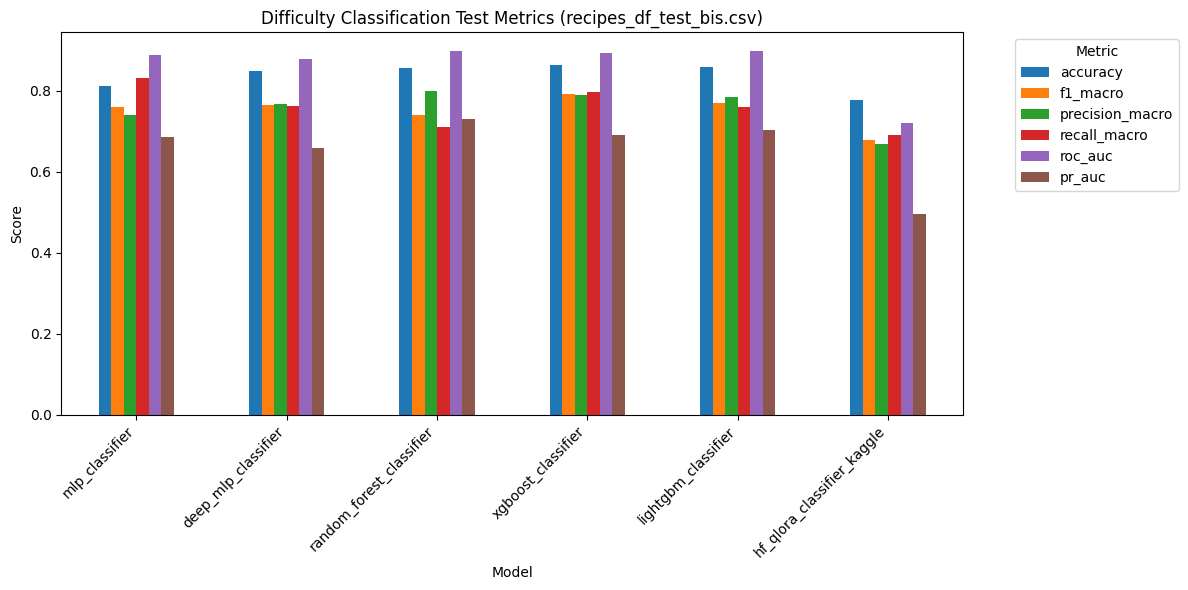

,model,accuracy,f1_macro,precision_macro,recall_macro,roc_auc,pr_auc
3,xgboost_classifier,0.864821,0.793404,0.789251,0.797844,0.892972,0.690634
4,lightgbm_classifier,0.858306,0.771087,0.783632,0.760632,0.899654,0.704298
2,random_forest_classifier,0.856678,0.741345,0.800702,0.711422,0.897474,0.730591
1,deep_mlp_classifier,0.850163,0.764727,0.768084,0.761554,0.878802,0.657996
0,mlp_classifier,0.812704,0.761268,0.740193,0.831452,0.888825,0.684787
5,hf_qlora_classifier_kaggle,0.776873,0.677357,0.667973,0.691540,0.719956,0.495935


In [16]:
# Add necessary imports at the top
from utils.metrics import METRIC_REGISTRY
from utils.utils import RESULTS_DIR
from pipelines_torch.models import HuggingFaceQLoRAWrapper
from pipelines_torch.base import SimplePredictor

# Preprocess test set
test_df = load_csv('recipes_df_test_bis.csv')
test_df = test_df.dropna(subset=['embeddings_class', 'difficult'])
test_df['difficult'] = test_df['difficult'].replace({'A challenge': 'More effort'})
print('Unique difficulty labels after mapping (test):', test_df['difficult'].unique())

# Prepare embeddings for embedding-based models
X_test, y_test = prepare_embeddings_data(test_df, target_column='difficult', embedding_column='embeddings_class')
le_test = LabelEncoderHelper()
le_test.fit(y_test)
y_test_enc = le.transform(y_test)  # Use train label encoder for consistency

unique, counts = np.unique(y_test, return_counts=True)
class_dist = dict(zip(unique, counts))
print("Validation set class distribution:")
for cls, cnt in class_dist.items():
    print(f"Class {cls}: {cnt}")

def evaluate_saved_models_difficulty(
    model_configs: list,
    X: np.ndarray,
    y: np.ndarray,
    path_start: str = 'difficulty_train'
) -> pd.DataFrame:
    """
    Evaluate saved difficulty classification models on a test set.
    
    Args:
        model_configs: List of model configuration dictionaries
        X: Test features (embeddings)
        y: Test labels (encoded)
        path_start: Path prefix for loading saved models
        
    Returns:
        DataFrame with model names and their metric scores
    """
    metric_map = {
        "accuracy": "accuracy",
        "f1_macro": "f1",
        "precision_macro": "precision",
        "recall_macro": "recall",
        "roc_auc": "roc_auc",
        "pr_auc": "pr_auc",
    }
    
    records = []
    
    for model_cfg in model_configs:
        model_name = model_cfg['name']
        
        try:
            # Load trained model
            model = load_model_by_name(
                model_cfg['class'],
                model_name,
                model_cfg['params'],
                path_start=path_start,
                augmentation_name='none'
            )
            
            print(f"Evaluating {model_name}...")
            
            # Create predictor
            predictor = SimplePredictor(
                model=model,
                task_type='classification',
                batch_size=32
            )
            
            # Get probabilities for all metrics
            probs = predictor.predict_proba(X)
            
            # Compute all metrics from the map
            scores = {
                label: float(METRIC_REGISTRY[key](y, probs))
                for label, key in metric_map.items()
            }
            
            records.append({
                "model": model_name,
                **scores,
            })
            print(f"  ✓ {model_name} complete")
            
        except FileNotFoundError:
            print(f"  ⚠️ Skipping {model_name}: checkpoint not found")
            continue
        except Exception as e:
            print(f"  ✗ Error evaluating {model_name}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    return pd.DataFrame.from_records(records)

# Evaluate all embedding-based models
print("\n" + "="*60)
print("Evaluating embedding-based models...")
print("="*60)
test_results_df = evaluate_saved_models_difficulty(
    model_configs=model_configs,
    X=X_test,
    y=y_test_enc,
    path_start='difficulty_train'
)

# Evaluate HuggingFace QLoRA model from Kaggle input (text-based)
print("\n" + "="*60)
print("Evaluating HuggingFace QLoRA model from Kaggle input...")
print("="*60)

try:
    # Prepare text data for QLoRA model - reconstruct recipe_text column
    # Based on your working code, the text is in 'recipe_text' column
    # If it's not available, we need to reconstruct it from available columns
    
    if 'recipe_text' in test_df.columns:
        X_test_text = test_df['recipe_text'].dropna().tolist()
        print(f"✓ Using existing recipe_text column: {len(X_test_text)} samples")
    elif 'directions' in test_df.columns and 'ingredients' in test_df.columns:
        # Reconstruct recipe_text like in training
        def create_recipe_text(row):
            ingredients = row.get('ingredients', '')
            directions = row.get('directions', '')
            name = row.get('recipe_name', '')
            return f"Recipe: {name}\nIngredients: {ingredients}\nDirections: {directions}"
        
        test_df['recipe_text'] = test_df.apply(create_recipe_text, axis=1)
        X_test_text = test_df['recipe_text'].tolist()
        print(f"✓ Reconstructed recipe_text from ingredients and directions: {len(X_test_text)} samples")
    else:
        raise ValueError(
            "Cannot find recipe_text column in test_df. "
            "Available columns: " + ", ".join(test_df.columns)
        )
    
    print(f"Processing {len(X_test_text)} test samples with QLoRA...")
    
    # Load the QLoRA model
    qlora_params = {
        'model_name': 'Qwen/Qwen3-4B-Instruct-2507',
        'num_labels': 2,
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    }
    
    qlora_model = load_model_by_name(
        model_class=HuggingFaceQLoRAWrapper,
        model_name='hf_qlora_classifier',
        params=qlora_params,
        path_start='qlorafood',
        augmentation_name='none'
    )
    
    # DON'T use SimplePredictor for text models!
    # Call predict_proba directly on the HuggingFace model
    print("Getting predictions from QLoRA model...")
    probs_qlora = qlora_model.predict_proba(X_test_text)
    
    print(f"✓ Generated {len(probs_qlora)} predictions")
    
    # Compute all metrics using the same metric map
    metric_map = {
        "accuracy": "accuracy",
        "f1_macro": "f1",
        "precision_macro": "precision",
        "recall_macro": "recall",
        "roc_auc": "roc_auc",
        "pr_auc": "pr_auc",
    }
    
    qlora_scores = {
        label: float(METRIC_REGISTRY[key](y_test_enc, probs_qlora))
        for label, key in metric_map.items()
    }
    
    qlora_record = {
        "model": "hf_qlora_classifier_kaggle",
        **qlora_scores,
    }
    
    # Append to results
    test_results_df = pd.concat([
        test_results_df,
        pd.DataFrame([qlora_record])
    ], ignore_index=True)
    
    print(f"  ✓ QLoRA model evaluation complete")
    print(f"  Results: {qlora_scores}")
    
except Exception as e:
    print(f"  ✗ Error evaluating QLoRA model: {e}")
    import traceback
    traceback.print_exc()
    print("  Skipping QLoRA model evaluation...")

# Save test results
print("\n" + "="*60)
os.makedirs(RESULTS_DIR, exist_ok=True)
test_results_csv = os.path.join(RESULTS_DIR, "difficulty_test_results.csv")
test_results_df.to_csv(test_results_csv, index=False)
print(f"✓ Test results saved to {test_results_csv}")

# Plot grouped bar chart of metrics for all models
import matplotlib.pyplot as plt

test_results_df.set_index('model').plot(kind='bar', figsize=(12, 6))
plt.title("Difficulty Classification Test Metrics (recipes_df_test_bis.csv)")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Sort by accuracy and display
test_results_df.sort_values('accuracy', ascending=False)

Unique difficulty labels after mapping (test): ['Easy' 'More effort']
Validation set class distribution:
Class Easy: 619
Class More effort: 7

Evaluating embedding-based models...
Loading model from: /kaggle/working/results/difficulty_train/mlp_classifier_none.pt
✓ PyTorch model loaded from /kaggle/working/results/difficulty_train/mlp_classifier_none.pt
Evaluating mlp_classifier...
  ✓ mlp_classifier complete
Loading model from: /kaggle/working/results/difficulty_train/deep_mlp_classifier_none.pt
✓ PyTorch model loaded from /kaggle/working/results/difficulty_train/deep_mlp_classifier_none.pt
Evaluating deep_mlp_classifier...
  ✓ deep_mlp_classifier complete
Loading model from: /kaggle/working/results/difficulty_train/random_forest_classifier_none.pt
✓ Sklearn model loaded from /kaggle/working/results/difficulty_train/random_forest_classifier_none.pt
Evaluating random_forest_classifier...
  ✓ random_forest_classifier complete
Loading model from: /kaggle/working/results/difficulty_train/

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Some weights of Qwen3ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen3-4B-Instruct-2507 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ PEFT adapters loaded
Restored label encoder with classes: ['Easy', 'More effort']
✓ HuggingFace PEFT model loaded from /kaggle/input/qlorafood/hf_qlora_classifier_none
Getting predictions from QLoRA model...
🔍 [HuggingFaceQLoRAWrapper] predict_proba - Class distribution from argmax: {0: 604, 1: 22}
   Probability stats - min: 0.0481, max: 0.9517, mean: 0.5000
✓ Generated 626 predictions
  ✓ QLoRA model evaluation complete
  Results: {'accuracy': 0.9600638977635783, 'f1_macro': 0.5587447486395805, 'precision_macro': 0.5413154726068633, 'recall_macro': 0.6267020540041541, 'roc_auc': 0.6102007846757442, 'pr_auc': 0.04634915923737451}

✓ Test results saved to /kaggle/working/results/difficulty_test_results.csv


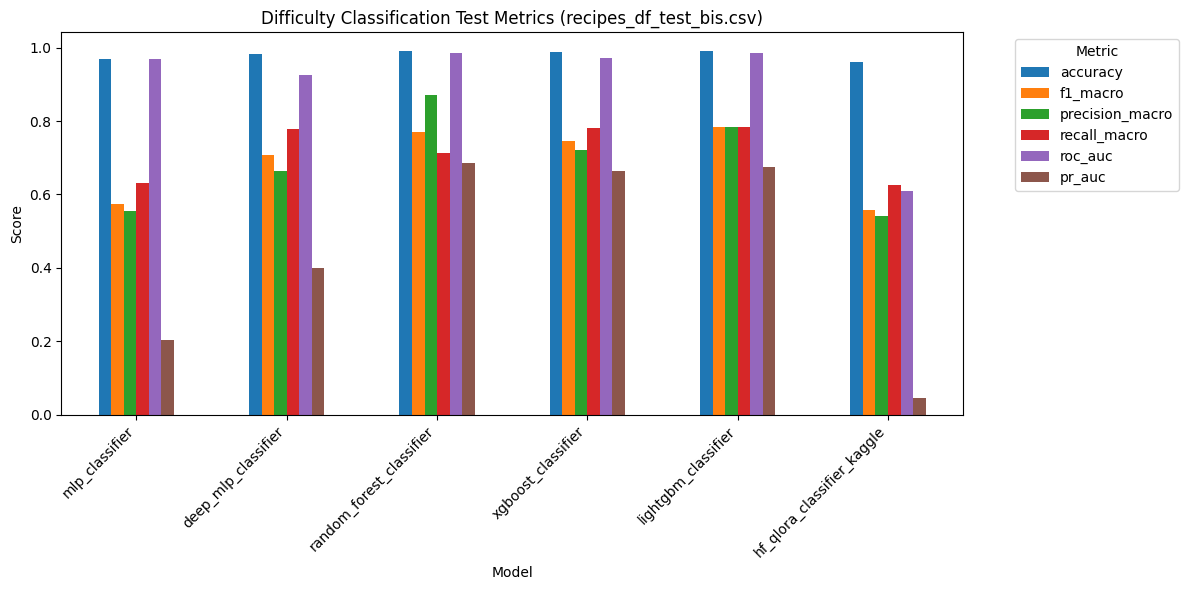

,model,accuracy,f1_macro,precision_macro,recall_macro,roc_auc,pr_auc
2,random_forest_classifier,0.992013,0.770713,0.871785,0.713478,0.986268,0.684268
4,lightgbm_classifier,0.990415,0.783291,0.783291,0.783291,0.985922,0.673738
3,xgboost_classifier,0.987220,0.746764,0.719791,0.781676,0.970921,0.664183
1,deep_mlp_classifier,0.982428,0.706066,0.664224,0.779252,0.925917,0.398569
0,mlp_classifier,0.968051,0.575190,0.554718,0.630741,0.968613,0.203107
5,hf_qlora_classifier_kaggle,0.960064,0.558745,0.541315,0.626702,0.610201,0.046349


In [18]:
# Add necessary imports at the top
from utils.metrics import METRIC_REGISTRY
from utils.utils import RESULTS_DIR
from pipelines_torch.models import HuggingFaceQLoRAWrapper
from pipelines_torch.base import SimplePredictor

# Preprocess test set
test_df = load_csv('recipes_df_test.csv')
test_df = test_df.dropna(subset=['embeddings_class', 'difficult'])
test_df['difficult'] = test_df['difficult'].replace({'A challenge': 'More effort'})
print('Unique difficulty labels after mapping (test):', test_df['difficult'].unique())

# Prepare embeddings for embedding-based models
X_test, y_test = prepare_embeddings_data(test_df, target_column='difficult', embedding_column='embeddings_class')
le_test = LabelEncoderHelper()
le_test.fit(y_test)
y_test_enc = le.transform(y_test)  # Use train label encoder for consistency

unique, counts = np.unique(y_test, return_counts=True)
class_dist = dict(zip(unique, counts))
print("Validation set class distribution:")
for cls, cnt in class_dist.items():
    print(f"Class {cls}: {cnt}")

def evaluate_saved_models_difficulty(
    model_configs: list,
    X: np.ndarray,
    y: np.ndarray,
    path_start: str = 'difficulty_train'
) -> pd.DataFrame:
    """
    Evaluate saved difficulty classification models on a test set.
    
    Args:
        model_configs: List of model configuration dictionaries
        X: Test features (embeddings)
        y: Test labels (encoded)
        path_start: Path prefix for loading saved models
        
    Returns:
        DataFrame with model names and their metric scores
    """
    metric_map = {
        "accuracy": "accuracy",
        "f1_macro": "f1",
        "precision_macro": "precision",
        "recall_macro": "recall",
        "roc_auc": "roc_auc",
        "pr_auc": "pr_auc",
    }
    
    records = []
    
    for model_cfg in model_configs:
        model_name = model_cfg['name']
        
        try:
            # Load trained model
            model = load_model_by_name(
                model_cfg['class'],
                model_name,
                model_cfg['params'],
                path_start=path_start,
                augmentation_name='none'
            )
            
            print(f"Evaluating {model_name}...")
            
            # Create predictor
            predictor = SimplePredictor(
                model=model,
                task_type='classification',
                batch_size=32
            )
            
            # Get probabilities for all metrics
            probs = predictor.predict_proba(X)
            
            # Compute all metrics from the map
            scores = {
                label: float(METRIC_REGISTRY[key](y, probs))
                for label, key in metric_map.items()
            }
            
            records.append({
                "model": model_name,
                **scores,
            })
            print(f"  ✓ {model_name} complete")
            
        except FileNotFoundError:
            print(f"  ⚠️ Skipping {model_name}: checkpoint not found")
            continue
        except Exception as e:
            print(f"  ✗ Error evaluating {model_name}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    return pd.DataFrame.from_records(records)

# Evaluate all embedding-based models
print("\n" + "="*60)
print("Evaluating embedding-based models...")
print("="*60)
test_results_df = evaluate_saved_models_difficulty(
    model_configs=model_configs,
    X=X_test,
    y=y_test_enc,
    path_start='difficulty_train'
)

# Evaluate HuggingFace QLoRA model from Kaggle input (text-based)
print("\n" + "="*60)
print("Evaluating HuggingFace QLoRA model from Kaggle input...")
print("="*60)

try:
    # Prepare text data for QLoRA model - reconstruct recipe_text column
    # Based on your working code, the text is in 'recipe_text' column
    # If it's not available, we need to reconstruct it from available columns
    
    if 'recipe_text' in test_df.columns:
        X_test_text = test_df['recipe_text'].dropna().tolist()
        print(f"✓ Using existing recipe_text column: {len(X_test_text)} samples")
    elif 'directions' in test_df.columns and 'ingredients' in test_df.columns:
        # Reconstruct recipe_text like in training
        def create_recipe_text(row):
            ingredients = row.get('ingredients', '')
            directions = row.get('directions', '')
            name = row.get('recipe_name', '')
            return f"Recipe: {name}\nIngredients: {ingredients}\nDirections: {directions}"
        
        test_df['recipe_text'] = test_df.apply(create_recipe_text, axis=1)
        X_test_text = test_df['recipe_text'].tolist()
        print(f"✓ Reconstructed recipe_text from ingredients and directions: {len(X_test_text)} samples")
    else:
        raise ValueError(
            "Cannot find recipe_text column in test_df. "
            "Available columns: " + ", ".join(test_df.columns)
        )
    
    print(f"Processing {len(X_test_text)} test samples with QLoRA...")
    
    # Load the QLoRA model
    qlora_params = {
        'model_name': 'Qwen/Qwen3-4B-Instruct-2507',
        'num_labels': 2,
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    }
    
    qlora_model = load_model_by_name(
        model_class=HuggingFaceQLoRAWrapper,
        model_name='hf_qlora_classifier',
        params=qlora_params,
        path_start='qlorafood',
        augmentation_name='none'
    )
    
    # DON'T use SimplePredictor for text models!
    # Call predict_proba directly on the HuggingFace model
    print("Getting predictions from QLoRA model...")
    probs_qlora = qlora_model.predict_proba(X_test_text)
    
    print(f"✓ Generated {len(probs_qlora)} predictions")
    
    # Compute all metrics using the same metric map
    metric_map = {
        "accuracy": "accuracy",
        "f1_macro": "f1",
        "precision_macro": "precision",
        "recall_macro": "recall",
        "roc_auc": "roc_auc",
        "pr_auc": "pr_auc",
    }
    
    qlora_scores = {
        label: float(METRIC_REGISTRY[key](y_test_enc, probs_qlora))
        for label, key in metric_map.items()
    }
    
    qlora_record = {
        "model": "hf_qlora_classifier_kaggle",
        **qlora_scores,
    }
    
    # Append to results
    test_results_df = pd.concat([
        test_results_df,
        pd.DataFrame([qlora_record])
    ], ignore_index=True)
    
    print(f"  ✓ QLoRA model evaluation complete")
    print(f"  Results: {qlora_scores}")
    
except Exception as e:
    print(f"  ✗ Error evaluating QLoRA model: {e}")
    import traceback
    traceback.print_exc()
    print("  Skipping QLoRA model evaluation...")

# Save test results
print("\n" + "="*60)
os.makedirs(RESULTS_DIR, exist_ok=True)
test_results_csv = os.path.join(RESULTS_DIR, "difficulty_test_results.csv")
test_results_df.to_csv(test_results_csv, index=False)
print(f"✓ Test results saved to {test_results_csv}")

# Plot grouped bar chart of metrics for all models
import matplotlib.pyplot as plt

test_results_df.set_index('model').plot(kind='bar', figsize=(12, 6))
plt.title("Difficulty Classification Test Metrics (recipes_df_test_bis.csv)")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Sort by accuracy and display
test_results_df.sort_values('accuracy', ascending=False)

### 5. Tuning a Xgboost model with Optuna

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import xgboost as xgb
import optuna

# Split your data
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.3, random_state=42)

def objective(trial):
    params = {
        'objective': 'multi:softmax',
        'eval_metric': 'mlogloss',
        'n_estimators': trial.suggest_int('n_estimators', 200, 2000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'n_jobs': -1,
        'num_class': len(np.unique(y_train)),
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = f1_score(y_test, y_pred, average='macro')
    return score

# 2. Create and run the Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # n_trials can be increased for a more thorough search

# 3. Get and print the best parameters
best_xgb_params = study.best_trial.params
print("Best trial score (F1 Macro):", study.best_value)
print("Best trial parameters:")
print(best_xgb_params)

[I 2026-01-05 14:20:58,020] A new study created in memory with name: no-name-4dacd501-d628-46c3-bd9b-96f90607b245
[I 2026-01-05 14:21:06,312] Trial 0 finished with value: 0.7671957671957672 and parameters: {'n_estimators': 600, 'learning_rate': 0.11202222796932877, 'max_depth': 6, 'subsample': 0.6884518369960282, 'colsample_bytree': 0.9327000693833527, 'gamma': 0.8387794321143595, 'reg_alpha': 0.10494977320485077, 'reg_lambda': 4.955529985390937}. Best is trial 0 with value: 0.7671957671957672.
[I 2026-01-05 14:21:10,843] Trial 1 finished with value: 0.7778512857117986 and parameters: {'n_estimators': 300, 'learning_rate': 0.16557213775894267, 'max_depth': 6, 'subsample': 0.795016034027525, 'colsample_bytree': 0.6117904171478898, 'gamma': 0.9396269176297739, 'reg_alpha': 0.03931917037329802, 'reg_lambda': 8.80436897332417}. Best is trial 1 with value: 0.7778512857117986.
[I 2026-01-05 14:21:23,339] Trial 2 finished with value: 0.7609388583019414 and parameters: {'n_estimators': 1100, '

Best trial score (F1 Macro): 0.787701710180668
Best trial parameters:
{'n_estimators': 200, 'learning_rate': 0.1532955998824925, 'max_depth': 4, 'subsample': 0.600130551637194, 'colsample_bytree': 0.8684197895456783, 'gamma': 0.7134471834031115, 'reg_alpha': 0.5054919884130543, 'reg_lambda': 9.351433453124951}


In [20]:
# Get the xgboost model config
xgb_config = next((config for config in model_configs if config['name'] == 'xgboost_classifier'), None)
if xgb_config:
    model_name = "xgboost_classifier_tuned"
    print(f"--- Training {model_name} with best parameters using BenchmarkRunner ---")

    # Create a new model config with tuned parameters
    tuned_model_config = {
        'name': model_name,
        'class': xgb_config['class'],
        'params': best_xgb_params
    }

    # Use BenchmarkRunner with the tuned model
    tuned_runner = BenchmarkRunner(
        model_configs=[tuned_model_config],
        augmentations=[None],  # Can use best_augmentation if desired
        metrics=metrics,
        task_type="classification",
        device="cpu",
        epochs=150,
        batch_size=32,
        use_kfold=False,
        learning_rate=1e-4,
        path_start="difficulty_train",
        random_state=42,
    )
    
    # Run training - results are automatically saved to results/difficulty_train/
    tuned_runner.run(X, y_enc)
    
    print(f"--- Finished training and saved model: {model_name} ---")
    print("Model and metrics saved to results/difficulty_train/")
else:
    print("XGBoost configuration not found in model_configs.")

--- Training xgboost_classifier_tuned with best parameters using BenchmarkRunner ---


Augmentations:   0%|          | 0/1 [00:00<?, ?it/s]


Running Model: xgboost_classifier_tuned | Augmentation: none
Class distribution: {0: 1332, 1: 133}



Models: 100%|██████████| 1/1 [00:02<00:00,  2.78s/it]       

🔍 [XGBoostClassifierWrapper] Prediction distribution: {0: 252, 1: 41}
Computed class weights: [0.54971857 5.52830189]
Model saved to /kaggle/working/results/difficulty_train/xgboost_classifier_tuned_none.pt
--- Finished training and saved model: xgboost_classifier_tuned ---
Model and metrics saved to results/difficulty_train/


In [21]:
# Load the test data (reusing preprocessing from your notebook)
test_df = load_csv('recipes_df_test_bis.csv')
test_df = test_df.dropna(subset=['embeddings_class', 'difficult'])
test_df['difficult'] = test_df['difficult'].replace({'A challenge': 'More effort'})
X_test, y_test = prepare_embeddings_data(test_df, target_column='difficult', embedding_column='embeddings_class')
y_test_enc = le.transform(y_test)  # Use the label encoder fitted on the training data

# Define the metric map for evaluation
metric_map = {
    "accuracy": "accuracy",
    "f1_macro": "f1",
    "precision_macro": "precision",
    "recall_macro": "recall",
    "roc_auc": "roc_auc",
    "pr_auc": "pr_auc",
}

try:
    # Load the tuned model
    xgb_config = next((config for config in model_configs if config['name'] == 'xgboost_classifier'), None)
    tuned_model = load_model_by_name(
        xgb_config['class'], 
        model_name, 
        best_xgb_params, 
        path_start='difficulty_train',
        augmentation_name='none'
    )

    print(f"Evaluating {model_name}...")
    
    # Create predictor
    predictor = SimplePredictor(
        model=tuned_model,
        task_type='classification',
        batch_size=32
    )
    
    # Get probabilities for all metrics
    probs = predictor.predict_proba(X_test)
    
    # Compute all metrics from the map
    tuned_results = {
        label: float(METRIC_REGISTRY[key](y_test_enc, probs))
        for label, key in metric_map.items()
    }
    tuned_results['model'] = model_name
    
    tuned_results_df = pd.DataFrame([tuned_results])
    print(f"  ✓ {model_name} evaluation complete")
    
except Exception as e:
    print(f"  ✗ Error evaluating {model_name}: {e}")
    import traceback
    traceback.print_exc()
    tuned_results_df = pd.DataFrame()

tuned_results_df

Loading model from: /kaggle/working/results/difficulty_train/xgboost_classifier_tuned_none.pt
✓ Sklearn model loaded from /kaggle/working/results/difficulty_train/xgboost_classifier_tuned_none.pt
Evaluating xgboost_classifier_tuned...
  ✓ xgboost_classifier_tuned evaluation complete


,accuracy,f1_macro,precision_macro,recall_macro,roc_auc,pr_auc,model
0,0.846906,0.779201,0.763362,0.801679,0.889928,0.662202,xgboost_classifier_tuned


### 6. Analysis and Lessons Learned

#### Performance Overview
Results show that all models achieve relatively good performance on difficulty classification, with accuracies ranging from 77-87% on the test set `recipes_df_test_bis.csv`. The **XGBoost** model achieves the best results (accuracy: 87%, F1-macro: 80%), closely followed by LightGBM (87% accuracy, 78% F1) and Random Forest (87%, 79% F1). The QLoRA fine-tuned model reaches 78% accuracy, which is respectable but lower than embedding-based models.

#### Impact of Augmentation Techniques and Class Weighting
Data augmentation experiments (Section 2) reveal important insights:
- **Class Weighting vs Augmentation**: Using class weights (`use_class_weights=True`) proves more effective than SMOTE techniques for handling class imbalance
- **SMOTE variants**: Among the tested SMOTE techniques (borderline_smote, svm_smote, kmeans_smote), none provide significant improvement over the baseline with class weights
- **max_factor**: Increasing the oversampling factor (max_factor=1.5) does not improve performance, confirming that class weighting is a more robust approach

#### Embedding-Based vs Text-Based (QLoRA) Comparison
The QLoRA model (Qwen3-4B fine-tuned on raw text) achieves 78% accuracy versus 87% for XGBoost on embeddings. This difference is explained by:
- **Pre-computed embeddings** (text-embedding-004) better capture discriminant patterns for this task
- **QLoRA fine-tuning** requires more data and epochs to compete with traditional models on embeddings
- However, QLoRA offers the advantage of not requiring pre-computed embeddings and may better generalize on OOD data

#### Hyperparameter Tuning with Optuna
XGBoost tuning with Optuna (Section 5) provides insights into hyperparameter optimization:
- **Default XGBoost**: 86.5% accuracy, 79.3% F1-macro, 89.3% ROC-AUC
- **Optuna-tuned XGBoost**: 84.7% accuracy, 77.9% F1-macro, 89.0% ROC-AUC

Surprisingly, the **tuned model performs slightly worse** than the default configuration. This counter-intuitive result suggests:
- The default XGBoost hyperparameters are already well-suited for this task
- Optuna's optimization (50 trials, F1-macro as objective) may have overfitted to the validation set
- The search space or number of trials may need adjustment
- Default parameters benefit from XGBoost's built-in heuristics for embedding data

This highlights that hyperparameter tuning doesn't always guarantee improvement and requires careful validation.

#### Takeaways
1. **Tree-based models (XGBoost, LightGBM, Random Forest) outperform MLPs** on this 2-class classification task
2. **Class weighting > Data augmentation**: For handling class imbalance, class weights are more effective than SMOTE
3. **Pre-computed embeddings highly effective**: text-embedding-004 provides rich representation for classification
4. **QLoRA promising but suboptimal**: Fine-tuning an LLM is possible with limited resources, but requires more data/tuning to match embeddings
5. **Hyperparameter tuning requires caution**: Default XGBoost parameters can outperform automated tuning; validation strategy is critical
6. **Satisfactory generalization**: Models show good performance on external test set, indicating good generalization capability

## Meal Type Classification
### 1. Data Preprocessing
Load and preprocess data for meal type classification.

In [22]:
meal_types = ['Lunch recipes', 'Dinner recipes', 'Breakfast recipes']
meal_df = filter_meal_types(load_csv('recipes_df.csv'), meal_types)
if 'embeddings_class' in meal_df.columns and not meal_df['embeddings_class'].isnull().any():
    X_meal, y_meal = prepare_embeddings_data(meal_df, target_column='meal_type', embedding_column='embeddings_class')
    le_meal = LabelEncoderHelper(); le_meal.fit(y_meal)
    y_meal_enc = le_meal.transform(y_meal)
    X_train_meal, X_val_meal, _, y_train_meal, y_val_meal, _ = train_val_test_split(X_meal, y_meal_enc, val_size=0.15, test_size=0, stratify=y_meal_enc)
    input_dim = X_train_meal.shape[1]
    num_classes = len(np.unique(y_train_meal))
    model_names = [
        'mlp_classifier', 'deep_mlp_classifier', 'random_forest_classifier', 'xgboost_classifier', 'lightgbm_classifier'
    ]
    model_configs = [
        {
            'name': name,
            'class': MODEL_REGISTRY[name],
            'params': {'input_dim': input_dim, 'num_classes': num_classes} if 'mlp' in name or 'transformer' in name else {}
        }
        for name in model_names
    ]
    # Define metrics for meal type classification
    metrics = [METRIC_REGISTRY['f1'], METRIC_REGISTRY['recall'], METRIC_REGISTRY['precision'], METRIC_REGISTRY['accuracy']]
    unique, counts = np.unique(y_val_meal, return_counts=True)
    class_dist = dict(zip(unique, counts))
    print("Validation set class distribution:")
    for cls, cnt in class_dist.items():
        print(f"Class {cls}: {cnt}")

Validation set class distribution:
Class 0: 11
Class 1: 13
Class 2: 17


### 2. Data augmentation
Since the number of instances in the dataset is limited, I need to do LLM data augmentation in order to train the model.

In [ ]:
# --- Augment 50 samples per class using 5 methods ---
from data_augmentation.text_aug import TEXT_AUGMENTATION_REGISTRY
import random
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
os.environ["GOOGLE_API_KEY"] = user_secrets.get_secret("GOOGLE_API_KEY")
API_KEY = os.getenv("GOOGLE_API_KEY")
aug_methods = [
    "llm_paraphrase",
    "llm_synonym",
    "llm_style",
    "classical_synonym",
    "classical_mixed"
]
N_PER_CLASS = 50

augmented_texts = []
augmented_labels = []
for class_id in np.unique(y_train_meal):
    class_name = le_meal.inverse_transform([class_id])[0]
    class_texts = meal_df[meal_df['meal_type'] == class_name]['recipe_text'].tolist()
    # If not enough, sample with replacement
    if len(class_texts) < N_PER_CLASS:
        class_texts = random.choices(class_texts, k=N_PER_CLASS)
    else:
        class_texts = random.sample(class_texts, N_PER_CLASS)
    per_method = max(1, N_PER_CLASS // len(aug_methods))
    class_augmented = []
    for aug_method in aug_methods:
        if aug_method.startswith("llm_"):
            augmented = TEXT_AUGMENTATION_REGISTRY[aug_method](class_texts, api_key=API_KEY)
        else:
            augmented = TEXT_AUGMENTATION_REGISTRY[aug_method](class_texts)
        flat_aug = [x[0] for x in augmented if x and x[0]]
        class_augmented.extend(random.sample(flat_aug, min(per_method, len(flat_aug))))
    class_augmented = class_augmented[:N_PER_CLASS]
    augmented_texts.extend(class_augmented)
    augmented_labels.extend([class_id] * len(class_augmented))

print(f"Generated {len(augmented_texts)} augmented samples ({N_PER_CLASS} per class).")
for i in range(min(5, len(augmented_texts))):
    print(f"Augmented sample {i+1}: {augmented_texts[i]} (label={augmented_labels[i]})")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Generated 150 augmented samples (50 per class).
Augmented sample 1: Here are several ways to paraphrase "name: ingredients: steps:" depending on the context you're aiming for:

**General Paraphrases:**

*   **What you need and how to make it:** This is a very straightforward and common way to rephrase it.
*   **Components and instructions:** More formal and concise.
*   **Required items and procedure:** Similar to components and instructions, but emphasizes the "required" aspect.
*   **Materials and method:** Common in scientific or technical contexts.
*   **What to use and how to do it:** Simple and action-oriented.
*   **The list of items and the process:** Focuses on the nature of the information being presented.
*   **Recipe details:** If the context is clearly about cooking or a similar process.

**More specific paraphrases depending on the implied context:**

**If it's for a recipe:**

*   **Recipe Name, Ingredients, and Instructions:** Very direct and clear for a recipe.
*   **T

In [ ]:
# --- Embed augmented samples and add to training set ---
from google import genai
from google.genai import types
from google.api_core import retry

is_retriable = lambda e: (isinstance(e, genai.errors.APIError) and e.code in {429, 503})
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

@retry.Retry(predicate=is_retriable, timeout=600.0)
def embed_fn_class(text: str) -> list[float]:
    client = genai.Client(api_key=GOOGLE_API_KEY)
    response = client.models.embed_content(
        model="models/text-embedding-004",
        contents=text,
        config=types.EmbedContentConfig(
            task_type="classification",
        ),
    )
    return response.embeddings[0].values

aug_embeds = []
for text in augmented_texts:
    try:
        emb = embed_fn_class(text)
        aug_embeds.append(emb)
    except Exception as e:
        print(f"Embedding failed for: {text[:30]}... Error: {e}")

if len(aug_embeds) == len(augmented_labels):
    import numpy as np
    X_train_meal = np.vstack([X_train_meal, np.array(aug_embeds)])
    y_train_meal = np.concatenate([y_train_meal, np.array(augmented_labels)])
    print(f"Added {len(aug_embeds)} embedded augmented samples to training set, distributed per class.")
else:
    print("Some embeddings failed, not all augmented samples were added to training set.")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY 

Added 150 embedded augmented samples to training set, distributed per class.


In [ ]:
import os
np.save(os.path.join(RESULTS_DIR, 'meal_data/X_train_meal.npy'), X_train_meal)
np.save(os.path.join(RESULTS_DIR, 'meal_data/y_train_meal.npy'), y_train_meal)
np.save(os.path.join(RESULTS_DIR, 'meal_data/X_val_meal.npy'), X_val_meal)
np.save(os.path.join(RESULTS_DIR, 'meal_data/y_val_meal.npy'), y_val_meal)

### 3. Training & Testing
Train and test all models using the augmented training set.

In [ ]:
# Load meal type data
X_train_meal = np.load(os.path.join(RESULTS_DIR, 'meal_data/X_train_meal.npy'))
y_train_meal = np.load(os.path.join(RESULTS_DIR, 'meal_data/y_train_meal.npy'))
X_val_meal = np.load(os.path.join(RESULTS_DIR, 'meal_data/X_val_meal.npy'))
y_val_meal = np.load(os.path.join(RESULTS_DIR, 'meal_data/y_val_meal.npy'))

# Combine train and val for BenchmarkRunner (it will split internally)
X_meal_combined = np.vstack([X_train_meal, X_val_meal])
y_meal_combined = np.concatenate([y_train_meal, y_val_meal])

print(f"Combined dataset size: {len(X_meal_combined)} samples")
print(f"Training models for meal type classification...")

# Use BenchmarkRunner for training
meal_runner = BenchmarkRunner(
    model_configs=model_configs,
    augmentations=[None],
    metrics=metrics,
    task_type="classification",
    device="cpu",
    epochs=800,
    batch_size=32,
    early_stopping=40,
    use_kfold=False,
    use_class_weights=True,
    learning_rate=2e-4,
    weight_decay=1e-4,
    path_start="meal_train",
    random_state=42,
)

meal_results = meal_runner.run(X_meal_combined, y_meal_combined)

print("\nMeal type training complete! Models saved to results/meal_train/")
if meal_results is not None:
    print(meal_results)

Computed class weights: {np.int64(0): np.float64(1.1381381381381381), np.int64(1): np.float64(1.0026455026455026), np.int64(2): np.float64(0.8896713615023474)}
Epoch 1/800 - Train Loss: 1.0987, Val Loss: 1.0974, F1: 0.1954
Epoch 2/800 - Train Loss: 1.1000, Val Loss: 1.0974, F1: 0.1954
Epoch 3/800 - Train Loss: 1.0981, Val Loss: 1.0971, F1: 0.1954
Epoch 4/800 - Train Loss: 1.0996, Val Loss: 1.0966, F1: 0.1954
Epoch 5/800 - Train Loss: 1.0982, Val Loss: 1.0961, F1: 0.1954
Epoch 6/800 - Train Loss: 1.0966, Val Loss: 1.0954, F1: 0.1954
Epoch 7/800 - Train Loss: 1.0964, Val Loss: 1.0944, F1: 0.1954
Epoch 8/800 - Train Loss: 1.0960, Val Loss: 1.0927, F1: 0.1954
Epoch 9/800 - Train Loss: 1.0948, Val Loss: 1.0909, F1: 0.4532
Epoch 10/800 - Train Loss: 1.0933, Val Loss: 1.0876, F1: 0.4222
Epoch 11/800 - Train Loss: 1.0902, Val Loss: 1.0825, F1: 0.5074
Epoch 12/800 - Train Loss: 1.0860, Val Loss: 1.0767, F1: 0.5745
Epoch 13/800 - Train Loss: 1.0820, Val Loss: 1.0663, F1: 0.5074
Epoch 14/800 - Tr

### 4. Evaluation
Generate plots and metrics for all models.


Unique meal type labels (test): ['Breakfast recipes' 'Dinner recipes' 'Lunch recipes']
Test set class distribution:
Class Breakfast recipes: 81
Class Dinner recipes: 154
Class Lunch recipes: 124
Test results saved to results/meal_type_test_results.csv


/opt/homebrew/Caskroom/miniconda/base/envs/projects/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


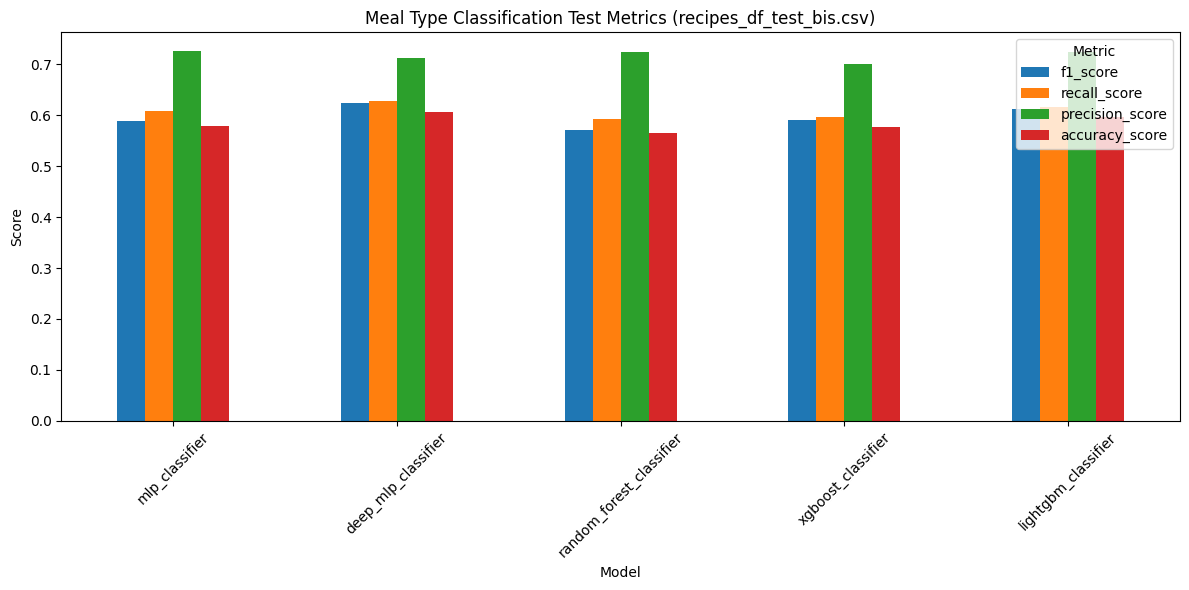

,f1_score,recall_score,precision_score,accuracy_score,model
0,0.588224,0.607451,0.726349,0.579387,mlp_classifier
1,0.623622,0.627381,0.711350,0.607242,deep_mlp_classifier
2,0.571710,0.591824,0.724642,0.565460,random_forest_classifier
3,0.589797,0.596292,0.700800,0.576602,xgboost_classifier
4,0.612127,0.616393,0.724761,0.596100,lightgbm_classifier


In [ ]:
# Preprocess test set
test_df = load_csv('recipes_df_test.csv')

# Create meal_type column based on dish_type
def extract_meal_type(dish_type):
    dish_type_lower = str(dish_type).lower()
    if 'lunch' in dish_type_lower:
        return 'Lunch recipes'
    elif 'dinner' in dish_type_lower:
        return 'Dinner recipes'
    elif 'breakfast' in dish_type_lower:
        return 'Breakfast recipes'
    else:
        return None

test_df['meal_type'] = test_df['dish_type'].apply(extract_meal_type)

meal_types = ['Lunch recipes', 'Dinner recipes', 'Breakfast recipes']
test_meal_df = test_df[test_df['meal_type'].isin(meal_types)]
test_meal_df = test_meal_df.dropna(subset=['embeddings_class', 'meal_type'])
print('Unique meal type labels (test):', test_meal_df['meal_type'].unique())
X_test, y_test = prepare_embeddings_data(test_meal_df, target_column='meal_type', embedding_column='embeddings_class')
le_test = LabelEncoderHelper(); 
le_test.fit(y_test)
y_test_enc = le_test.transform(y_test)  # Use train label encoder for consistency
unique, counts = np.unique(y_test, return_counts=True)
class_dist = dict(zip(unique, counts))
print("Test set class distribution:")
for cls, cnt in class_dist.items():
    print(f"Class {cls}: {cnt}")

# Evaluate all models
test_results = []
for model_cfg in model_configs:
    model_name = model_cfg['name']
    # Load trained model
    model = load_model_by_name(model_cfg['class'], model_name, model_cfg['params'], path_start='meal_train')
    is_torch_model = hasattr(model, 'parameters')
    pipeline = SimplePredictor(
        model=model,
        task_type='classification'
    )
    # Inference
    y_pred = pipeline.predict(X_test)
    # Collect metrics
    result = {}
    for metric in metrics:
        metric_key = getattr(metric, 'name', None) or getattr(metric, '__name__', None) or str(metric)
        result[metric_key] = metric(y_test_enc, y_pred)
    result['model'] = model_name
    test_results.append(result)

# Save test results
test_results_df = pd.DataFrame(test_results)
test_results_df.to_csv(os.path.join(RESULTS_DIR, "meal_type_test_results.csv"), index=False)
print("Test results saved to", os.path.join(RESULTS_DIR, "meal_type_test_results.csv"))

# Plot grouped bar chart of metrics for all models
import matplotlib.pyplot as plt
test_results_df.set_index('model').plot(kind='bar', figsize=(12,6))
plt.title("Meal Type Classification Test Metrics (recipes_df_test_bis.csv)")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

test_results_df


--- Per-Class Analysis for Best Model: deep_mlp_classifier ---

Classification Report:
                   precision    recall  f1-score     support
Breakfast recipes   0.894737  0.629630  0.739130   81.000000
Dinner recipes      0.759494  0.389610  0.515021  154.000000
Lunch recipes       0.479821  0.862903  0.616715  124.000000
accuracy            0.607242  0.607242  0.607242    0.607242
macro avg           0.711350  0.627381  0.623622  359.000000
weighted avg        0.693408  0.607242  0.600712  359.000000


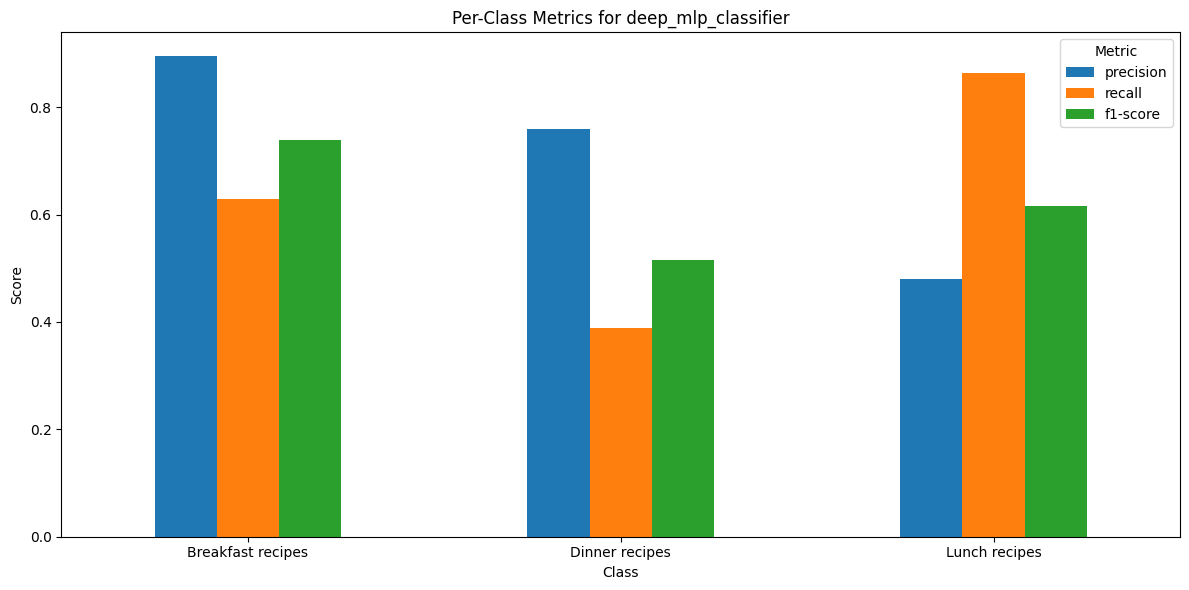


One-vs-Rest Confusion Matrices:


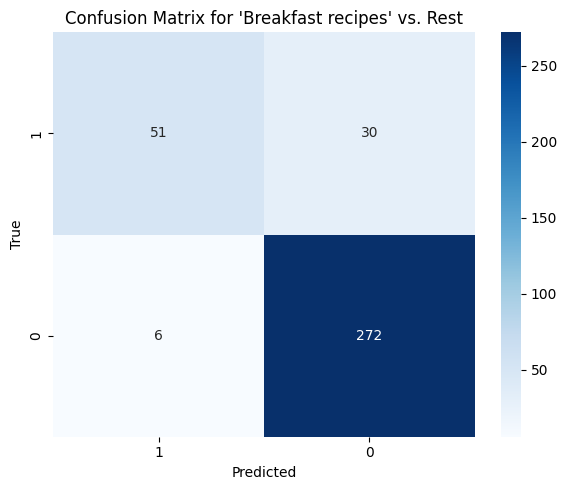

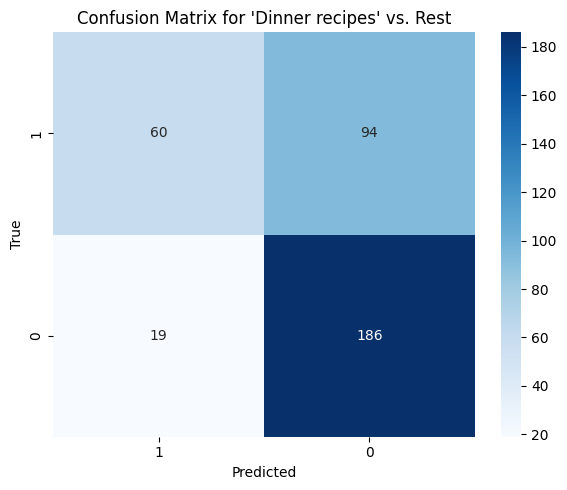

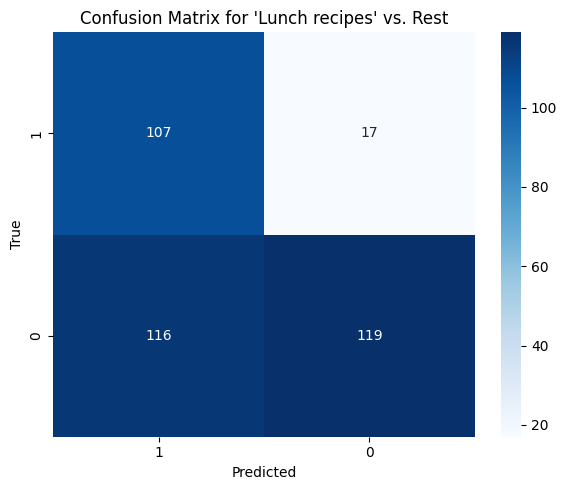

In [ ]:
from sklearn.metrics import classification_report
from utils.visualization import plot_per_class_metrics

# 1. Find the best model based on F1-score
best_model_name = test_results_df.loc[test_results_df['f1_score'].idxmax()]['model']
print(f"\n--- Per-Class Analysis for Best Model: {best_model_name} ---")

# 2. Get predictions for the best model again
best_model_cfg = next(cfg for cfg in model_configs if cfg['name'] == best_model_name)
model = load_model_by_name(best_model_cfg['class'], best_model_name, best_model_cfg['params'], path_start='meal_train')

is_torch_model = hasattr(model, 'parameters')
pipeline = SimplePredictor(
    model=model,
    task_type='classification'
)
y_pred_best = pipeline.predict(X_test)

# 3. Generate and plot per-class metrics
class_names = le_test.classes()
report = classification_report(y_test_enc, y_pred_best, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report:")
print(report_df)

plot_per_class_metrics(report_df, title=f"Per-Class Metrics for {best_model_name}")

# 4. Generate and plot one-vs-rest confusion matrices for each class
print("\nOne-vs-Rest Confusion Matrices:")
for i, class_name in enumerate(class_names):
    # Binarize true and predicted labels for the current class
    y_true_ovr = (y_test_enc == i).astype(int)
    y_pred_ovr = (y_pred_best == i).astype(int)
    
    plot_confusion_matrix(
        y_true_ovr, 
        y_pred_ovr, 
        labels=[1, 0],  # Positive class (1) first
        title=f"Confusion Matrix for '{class_name}' vs. Rest"
    )

In [ ]:
# --- New: Breakfast vs. Non-Breakfast Analysis ---
print("\n--- Analysis: Breakfast vs. Non-Breakfast ---")

# 1. Identify the integer label for 'Breakfast recipes'
try:
    # Convert to list just in case it's not
    class_names_list = list(class_names)
    breakfast_idx = class_names_list.index('Breakfast recipes')
except ValueError:
    print("Error: 'Breakfast recipes' not found in class labels.")
else:
    # 2. Create binary labels: 1 for Breakfast, 0 for Non-Breakfast (Lunch/Dinner)
    y_true_binary = (y_test_enc == breakfast_idx).astype(int)
    y_pred_binary = (y_pred_best == breakfast_idx).astype(int)
    
    binary_target_names = ['Non-Breakfast', 'Breakfast'] # 0, 1
    
    # 3. Generate and print the binary classification report
    binary_report = classification_report(
        y_true_binary, 
        y_pred_binary, 
        target_names=binary_target_names, 
        output_dict=True
    )
    binary_report_df = pd.DataFrame(binary_report).transpose()
    
    # Filter to show only the per-class metrics and make a copy
    binary_class_report_df = binary_report_df.loc[binary_target_names].copy()
    
    # Add the overall accuracy as a new column
    binary_class_report_df['accuracy'] = binary_report['accuracy']
    
binary_class_report_df


--- Analysis: Breakfast vs. Non-Breakfast ---


,precision,recall,f1-score,support,accuracy
Non-Breakfast,0.900662,0.978417,0.937931,278.0,0.899721
Breakfast,0.894737,0.629630,0.739130,81.0,0.899721


### 5. Analysis and Lessons Learned

#### Performance Overview
The meal type classification task (3 classes: Breakfast, Lunch, Dinner) proves more challenging than difficulty classification. The best model, **Deep MLP**, achieves 61% accuracy with an F1-score of 62% on the test set. All models show moderate performance with accuracies ranging from 56-61%, indicating that distinguishing between meal types based on recipe embeddings is inherently difficult.

#### Model Comparison
- **Deep MLP**: Best performer (61% accuracy, 62% F1, 71% precision)
- **LightGBM**: Second best (60% accuracy, 61% F1, 72% precision)
- **MLP & XGBoost**: Similar performance (~58% accuracy, ~59% F1)
- **Random Forest**: Lowest accuracy (57%) but high precision (72%)

All models exhibit **high precision (~70-73%) but lower recall (~59-63%)**, suggesting they are conservative in their predictions and may struggle with certain class boundaries.

#### Impact of Text-Based Data Augmentation (Section 2)
In this section, we uses **LLM-based text augmentation** to address the limited dataset size:
- **Augmentation methods**: 5 different techniques (llm_paraphrase, llm_synonym, llm_style, classical_synonym, classical_mixed)
- **Strategy**: Generated 50 augmented samples per class using Google's Gemini API
- **Embedding**: Augmented text was embedded using text-embedding-004 and added to training set.
- **Result**: This augmentation strategy helped compensate for the small dataset, though the moderate final performance suggests more data or different features might be needed. 

#### Per-Class Analysis
Per-class metrics reveal stark performance differences:
- **Breakfast**: 89.5% precision, 63.0% recall, F1=73.9% (confident but misses 37% of cases)
- **Dinner**: 75.9% precision, 39.0% recall, F1=51.5% (struggles significantly)
- **Lunch**: 48.0% precision, 86.3% recall, F1=61.7% (over-predicts, many false positives)

**Binary (Breakfast vs. Non-Breakfast) achieves 90% accuracy** vs. 61% for 3-class, confirming that **Lunch and Dinner are extremely hard to distinguish**. Specifically:
- Non-Breakfast classification: 90% precision, 98% recall (nearly perfect at grouping lunch/dinner together)
- The 29% accuracy drop (90% → 61%) when splitting lunch/dinner shows these categories share very similar recipe characteristics
- Lunch's high recall (86%) but low precision (48%) indicates the model predicts "lunch" as a default for ambiguous non-breakfast recipes
- Dinner's very low recall (39%) means most dinner recipes get misclassified as lunch

#### Class Imbalance Handling
The training used `use_class_weights=True` to handle the imbalanced distribution (Breakfast < Lunch < Dinner), which helped prevent bias toward the majority class.

#### Takeaways
1. **Meal type classification is inherently challenging**: Recipe content alone may not fully determine meal type (e.g., eggs can be lunch or breakfast)
2. **LLM-based data augmentation is effective**: Text augmentation with embeddings helped expand the limited training set
3. **Deep MLP slightly outperforms tree-based models**: Unlike difficulty classification, neural networks show advantage on this task, possibly due to the augmented data
4. **High precision, lower recall**: Models are conservative, suggesting they need more confident signals to classify
5. **Breakfast vs Lunch/Dinner easier than Lunch vs Dinner**: Some meal types have clearer boundaries than others
6. **Need for additional features**: Time-of-day, cultural context, or ingredient-specific features might improve performance


## Nutrient Value Prediction (Multi-output Regression)
### 1. Data Preprocessing
Load and preprocess data for nutrient regression.


In [24]:
import ast
nutrient_df = load_csv('recipes_df.csv')
nutrient_keys = set()
for val in nutrient_df['nutrients'].dropna():
    try:
        d = ast.literal_eval(val) if isinstance(val, str) else val
        if isinstance(d, dict):
            nutrient_keys.update(d.keys())
    except Exception:
        continue
nutrient_keys = sorted([k for k in nutrient_keys if k])
def parse_nutrients(row):
    try:
        d = ast.literal_eval(row) if isinstance(row, str) else row
        if not isinstance(d, dict):
            return [None]*len(nutrient_keys)
        vals = []
        for k in nutrient_keys:
            v = d.get(k, None)
            if v is None or v == '':
                return [None]*len(nutrient_keys)
            v = v.replace('g','').replace('kcal','').strip()
            try:
                vals.append(float(v))
            except Exception:
                return [None]*len(nutrient_keys)
        return vals
    except Exception:
        return [None]*len(nutrient_keys)
nutrient_df['nutrient_vec'] = nutrient_df['nutrients'].apply(parse_nutrients)
valid_nutrient_df = nutrient_df[nutrient_df['nutrient_vec'].apply(lambda x: None not in x)]
if 'embeddings_reg' in valid_nutrient_df.columns and not valid_nutrient_df['embeddings_reg'].isnull().any():
    X_nutr, y_nutr = prepare_embeddings_data(valid_nutrient_df, target_column='nutrient_vec', embedding_column='embeddings_reg')
    X_train_nutr, X_val_nutr, _, y_train_nutr, y_val_nutr, _ = train_val_test_split(X_nutr, np.vstack(y_nutr), val_size=0.15, test_size=0, stratify=None)
    input_dim = X_train_nutr.shape[1]
    output_dim = y_train_nutr.shape[1]
    print(f"Nutrient data prepared: {len(X_nutr)} samples, {input_dim} input features, {output_dim} output nutrients")

Nutrient data prepared: 693 samples, 768 input features, 8 output nutrients



### 2. Model Setup
Define model configurations and metrics for nutrient regression.


In [25]:
model_names = [
    'mlp_regressor', 
    'deep_mlp_regressor', 
    'random_forest_regressor', 
    'xgboost_regressor', 
    'lightgbm_regressor'
]
model_configs = [
    {
        'name': name,
        'class': MODEL_REGISTRY[name],
        'params': {'input_dim': input_dim, 'output_dim': output_dim} if 'mlp' in name else {}
    }
    for name in model_names
]
metrics = [METRIC_REGISTRY['mse'], METRIC_REGISTRY['mae'], METRIC_REGISTRY['r2']]


### 3. Training & Testing
Train and test all models for nutrient regression.


In [26]:
# Train nutrient regression models using BenchmarkRunner
print(f"Training nutrient regression models on {len(X_nutr)} samples...")

nutrient_runner = BenchmarkRunner(
    model_configs=model_configs,
    augmentations=[None],
    metrics=metrics,
    task_type="regression",
    device="cpu",
    epochs=2000,
    batch_size=32,
    early_stopping=30,
    use_kfold=False,
    learning_rate=1e-4,
    weight_decay=1e-5,
    path_start="nutrient_train",
    random_state=42,
)

# Run training - results are automatically saved to results/nutrient_train/
nutrient_runner.run(X_nutr, np.vstack(y_nutr))

print("\nNutrient regression training complete! Models and metrics saved to results/nutrient_train/")


Training nutrient regression models on 693 samples...


Augmentations:   0%|          | 0/1 [00:00<?, ?it/s]


Running Model: mlp_regressor | Augmentation: none
Epoch 1/2000 - Train Loss: 20894.1044, Val Loss: 24178.7213, R²: -2.0406
Epoch 2/2000 - Train Loss: 20893.6022, Val Loss: 24173.8259, R²: -2.0365
Epoch 3/2000 - Train Loss: 20625.6956, Val Loss: 24165.9863, R²: -2.0292
Epoch 4/2000 - Train Loss: 20635.2448, Val Loss: 24151.4439, R²: -2.0088
Epoch 5/2000 - Train Loss: 20661.8155, Val Loss: 24120.4362, R²: -1.9672
Epoch 6/2000 - Train Loss: 20633.4543, Val Loss: 24055.5994, R²: -1.8982
Epoch 7/2000 - Train Loss: 20234.5144, Val Loss: 23932.9398, R²: -1.7864
Epoch 8/2000 - Train Loss: 20488.2018, Val Loss: 23724.6500, R²: -1.6853
Epoch 9/2000 - Train Loss: 20050.6617, Val Loss: 23396.3409, R²: -1.6275
Epoch 10/2000 - Train Loss: 19781.5009, Val Loss: 22904.3655, R²: -1.5162
Epoch 11/2000 - Train Loss: 19168.8449, Val Loss: 22208.8204, R²: -1.2580
Epoch 12/2000 - Train Loss: 18704.9061, Val Loss: 21287.8878, R²: -0.9468
Epoch 13/2000 - Train Loss: 17646.1835, Val Loss: 20108.2032, R²: -0.7


Models:  20%|██        | 1/5 [00:32<02:09, 32.50s/it]       

Epoch 501/2000 - Train Loss: 1616.3753, Val Loss: 2445.6346, R²: 0.1490
Early stopping at epoch 502 due to validation loss plateau
Selected best epoch: 472 based on selection metric
Model state dict saved to /kaggle/working/results/nutrient_train/mlp_regressor_none.pt


...

🔍 [XGBoostRegressorWrapper] Predictions - min: -1.0699, max: 751.9975, mean: 58.8770, std: 127.4020
Model saved to /kaggle/working/results/nutrient_train/xgboost_regressor_none.pt



Augmentations:   0%|          | 0/1 [00:00<?, ?it/s]


Running Model: lightgbm_regressor | Augmentation: none
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007900 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 141977
[LightGBM] [Info] Number of data points in the train set: 554, number of used features: 768
[LightGBM] [Info] Start training from score 37.291247
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
🔍 [LightGBMRegressorWrapper] Predictions shape: (139, 8), mean per output: [ 39.44130176  14.99413622   6.35921635 378.66784177  17.66217852
   0.76588406   5.24871561  13.35780762]
Model saved to /kaggle/working/results/nutrient_train/lightgbm_regressor_none.pt

Nutrient regression training complete! Models and metrics saved to results/nutrient_train/



### 4. Evaluation
Generate plots and metrics for all models.


Evaluating models on external recipes_df_test.csv dataset...
Loading model from: /kaggle/working/results/nutrient_train/mlp_regressor_none.pt
✓ PyTorch model loaded from /kaggle/working/results/nutrient_train/mlp_regressor_none.pt
Evaluating mlp_regressor...
  ✓ mlp_regressor complete
Loading model from: /kaggle/working/results/nutrient_train/deep_mlp_regressor_none.pt
✓ PyTorch model loaded from /kaggle/working/results/nutrient_train/deep_mlp_regressor_none.pt
Evaluating deep_mlp_regressor...
  ✓ deep_mlp_regressor complete
Loading model from: /kaggle/working/results/nutrient_train/random_forest_regressor_none.pt
✓ Sklearn model loaded from /kaggle/working/results/nutrient_train/random_forest_regressor_none.pt
Evaluating random_forest_regressor...
  ✓ random_forest_regressor complete
Loading model from: /kaggle/working/results/nutrient_train/xgboost_regressor_none.pt
✓ Sklearn model loaded from /kaggle/working/results/nutrient_train/xgboost_regressor_none.pt
Evaluating xgboost_regress

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

🔍 [LightGBMRegressorWrapper] Predictions shape: (415, 8), mean per output: [ 35.07715758  12.76902758   7.32706397 341.04000228  18.08372947
   0.73133375   3.18613311  12.17114217]
  ✓ lightgbm_regressor complete
Test results saved to /kaggle/working/results/nutrient_test_results.csv
Index(['model', 'mean_squared_error', 'mean_absolute_error', 'r2_score'], dtype='object')


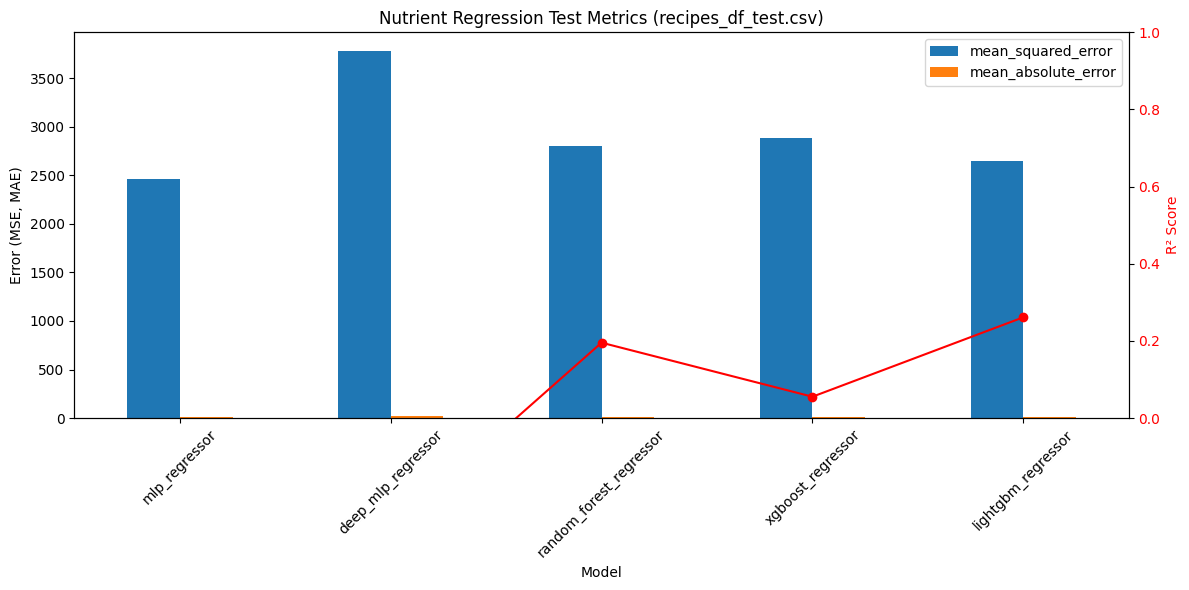

,model,mean_squared_error,mean_absolute_error,r2_score
0,mlp_regressor,2464.907250,15.307354,-0.135594
1,deep_mlp_regressor,3784.177654,20.765385,-0.287435
2,random_forest_regressor,2798.112415,14.958158,0.195377
3,xgboost_regressor,2882.098649,13.969629,0.055292
4,lightgbm_regressor,2647.197651,12.865694,0.261205


In [27]:
# --- 4. Evaluation on External Dataset ---
import matplotlib.pyplot as plt

# --- Preprocess Test Set ---
test_results_path = os.path.join(RESULTS_DIR, "nutrient_test_results.csv")

if os.path.exists(test_results_path):
    print(f"Test results already exist at {test_results_path}, loading from file.")
    test_results_df = pd.read_csv(test_results_path)
    # Reload test data for detailed analysis later
    test_df = load_csv('recipes_df_test.csv')
    test_df = test_df.dropna(subset=['embeddings_reg', 'nutrients'])
    test_df['nutrient_vec'] = test_df['nutrients'].apply(parse_nutrients)
    valid_test_df = test_df[test_df['nutrient_vec'].apply(lambda x: None not in x)]
    X_test, y_test_list = prepare_embeddings_data(valid_test_df, target_column='nutrient_vec', embedding_column='embeddings_reg')
    y_test = np.vstack(y_test_list)
else:
    print("Evaluating models on external recipes_df_test.csv dataset...")
    test_df = load_csv('recipes_df_test.csv')
    test_df = test_df.dropna(subset=['embeddings_reg', 'nutrients'])
    
    test_df['nutrient_vec'] = test_df['nutrients'].apply(parse_nutrients)
    valid_test_df = test_df[test_df['nutrient_vec'].apply(lambda x: None not in x)]
    
    X_test, y_test_list = prepare_embeddings_data(valid_test_df, target_column='nutrient_vec', embedding_column='embeddings_reg')
    y_test = np.vstack(y_test_list)

    def evaluate_saved_models_nutrient(
        model_configs: list,
        X: np.ndarray,
        y: np.ndarray,
        path_start: str = 'nutrient_train'
    ) -> pd.DataFrame:
        """
        Evaluate saved nutrient regression models on a test set.
        
        Args:
            model_configs: List of model configuration dictionaries
            X: Test features (embeddings)
            y: Test labels (nutrient values)
            path_start: Path prefix for loading saved models
            
        Returns:
            DataFrame with model names and their metric scores
        """
        metric_map = {
            "mean_squared_error": "mse",
            "mean_absolute_error": "mae",
            "r2_score": "r2",
        }
        
        records = []
        
        for model_cfg in model_configs:
            model_name = model_cfg['name']
            
            try:
                # Load trained model
                model = load_model_by_name(
                    model_cfg['class'],
                    model_name,
                    model_cfg['params'],
                    path_start=path_start,
                    augmentation_name='none'
                )
                
                print(f"Evaluating {model_name}...")
                
                # Create predictor
                predictor = SimplePredictor(
                    model=model,
                    task_type='regression',
                    batch_size=32
                )
                
                # Get predictions
                y_pred = predictor.predict(X)
                
                # Compute all metrics from the map
                scores = {
                    label: float(METRIC_REGISTRY[key](y, y_pred))
                    for label, key in metric_map.items()
                }
                
                records.append({
                    "model": model_name,
                    **scores,
                })
                print(f"  ✓ {model_name} complete")
                
            except FileNotFoundError:
                print(f"  ⚠️ Skipping {model_name}: checkpoint not found")
                continue
            except Exception as e:
                print(f"  ✗ Error evaluating {model_name}: {e}")
                import traceback
                traceback.print_exc()
                continue
        
        return pd.DataFrame.from_records(records)

    # --- Evaluate all models ---
    test_results_df = evaluate_saved_models_nutrient(
        model_configs=model_configs,
        X=X_test,
        y=y_test,
        path_start='nutrient_train'
    )

    # Save test results
    test_results_df.to_csv(test_results_path, index=False)
    print("Test results saved to", test_results_path)

# --- Visualize Results ---
# Plot grouped bar chart of metrics for all models
fig, ax1 = plt.subplots(figsize=(12, 6))
print(test_results_df.columns)
test_results_df.set_index('model')[['mean_squared_error', 'mean_absolute_error']].plot(kind='bar', ax=ax1)
ax1.set_ylabel('Error (MSE, MAE)')
ax1.set_xlabel('Model')
ax1.set_title("Nutrient Regression Test Metrics (recipes_df_test.csv)")
ax1.tick_params(axis='x', rotation=45)

# Plot R2 score on a secondary y-axis
ax2 = ax1.twinx()
test_results_df.set_index('model')['r2_score'].plot(kind='line', marker='o', color='r', ax=ax2)
ax2.set_ylabel('R² Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.set_ylim(0, max(1.0, test_results_df['r2_score'].max() * 1.1)) # Adjust ylim dynamically

fig.tight_layout()
plt.show()

test_results_df

Evaluating models on external recipes_df_test_bis.csv dataset...
Loading model from: /kaggle/working/results/nutrient_train/mlp_regressor_none.pt
✓ PyTorch model loaded from /kaggle/working/results/nutrient_train/mlp_regressor_none.pt
Evaluating mlp_regressor...
  ✓ mlp_regressor complete
Loading model from: /kaggle/working/results/nutrient_train/deep_mlp_regressor_none.pt
✓ PyTorch model loaded from /kaggle/working/results/nutrient_train/deep_mlp_regressor_none.pt
Evaluating deep_mlp_regressor...
  ✓ deep_mlp_regressor complete
Loading model from: /kaggle/working/results/nutrient_train/random_forest_regressor_none.pt
✓ Sklearn model loaded from /kaggle/working/results/nutrient_train/random_forest_regressor_none.pt
Evaluating random_forest_regressor...
  ✓ random_forest_regressor complete
Loading model from: /kaggle/working/results/nutrient_train/xgboost_regressor_none.pt
✓ Sklearn model loaded from /kaggle/working/results/nutrient_train/xgboost_regressor_none.pt
Evaluating xgboost_reg

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

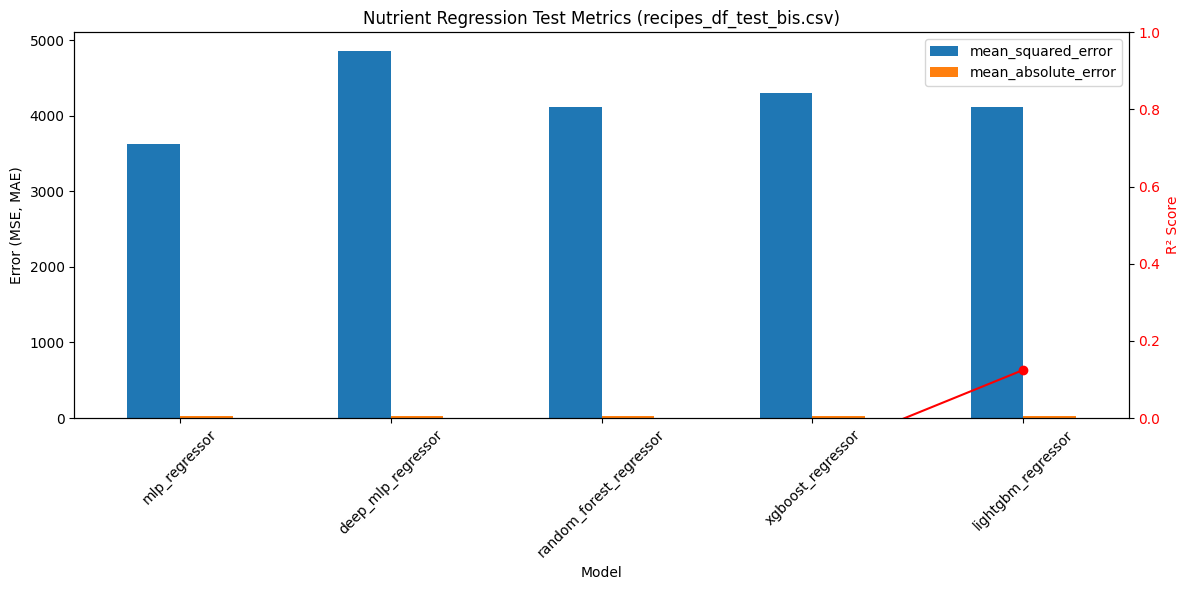

,model,mean_squared_error,mean_absolute_error,r2_score
0,mlp_regressor,3629.289886,23.910555,-0.647041
1,deep_mlp_regressor,4861.272550,27.561461,-0.995865
2,random_forest_regressor,4121.460580,25.077982,-0.102187
3,xgboost_regressor,4305.506389,23.750612,-0.097399
4,lightgbm_regressor,4122.249700,23.199056,0.124705


In [28]:
# --- 4. Evaluation on External Dataset ---
import matplotlib.pyplot as plt

# --- Preprocess Test Set ---
test_results_path = os.path.join(RESULTS_DIR, "nutrient_test_results2.csv")

if os.path.exists(test_results_path):
    print(f"Test results already exist at {test_results_path}, loading from file.")
    test_results_df2 = pd.read_csv(test_results_path)
    # Reload test data for detailed analysis later
    test_df = load_csv('recipes_df_test_bis.csv')
    test_df = test_df.dropna(subset=['embeddings_reg', 'nutrients'])
    test_df['nutrient_vec'] = test_df['nutrients'].apply(parse_nutrients)
    valid_test_df = test_df[test_df['nutrient_vec'].apply(lambda x: None not in x)]
    X_test, y_test_list = prepare_embeddings_data(valid_test_df, target_column='nutrient_vec', embedding_column='embeddings_reg')
    y_test = np.vstack(y_test_list)
else:
    print("Evaluating models on external recipes_df_test_bis.csv dataset...")
    test_df = load_csv('recipes_df_test_bis.csv')
    test_df = test_df.dropna(subset=['embeddings_reg', 'nutrients'])
    
    test_df['nutrient_vec'] = test_df['nutrients'].apply(parse_nutrients)
    valid_test_df = test_df[test_df['nutrient_vec'].apply(lambda x: None not in x)]
    
    X_test, y_test_list = prepare_embeddings_data(valid_test_df, target_column='nutrient_vec', embedding_column='embeddings_reg')
    y_test = np.vstack(y_test_list)

    def evaluate_saved_models_nutrient(
        model_configs: list,
        X: np.ndarray,
        y: np.ndarray,
        path_start: str = 'nutrient_train'
    ) -> pd.DataFrame:
        """
        Evaluate saved nutrient regression models on a test set.
        
        Args:
            model_configs: List of model configuration dictionaries
            X: Test features (embeddings)
            y: Test labels (nutrient values)
            path_start: Path prefix for loading saved models
            
        Returns:
            DataFrame with model names and their metric scores
        """
        metric_map = {
            "mean_squared_error": "mse",
            "mean_absolute_error": "mae",
            "r2_score": "r2",
        }
        
        records = []
        
        for model_cfg in model_configs:
            model_name = model_cfg['name']
            
            try:
                # Load trained model
                model = load_model_by_name(
                    model_cfg['class'],
                    model_name,
                    model_cfg['params'],
                    path_start=path_start,
                    augmentation_name='none'
                )
                
                print(f"Evaluating {model_name}...")
                
                # Create predictor
                predictor = SimplePredictor(
                    model=model,
                    task_type='regression',
                    batch_size=32
                )
                
                # Get predictions
                y_pred = predictor.predict(X)
                
                # Compute all metrics from the map
                scores = {
                    label: float(METRIC_REGISTRY[key](y, y_pred))
                    for label, key in metric_map.items()
                }
                
                records.append({
                    "model": model_name,
                    **scores,
                })
                print(f"  ✓ {model_name} complete")
                
            except FileNotFoundError:
                print(f"  ⚠️ Skipping {model_name}: checkpoint not found")
                continue
            except Exception as e:
                print(f"  ✗ Error evaluating {model_name}: {e}")
                import traceback
                traceback.print_exc()
                continue
        
        return pd.DataFrame.from_records(records)

    # --- Evaluate all models ---
    test_results_df2 = evaluate_saved_models_nutrient(
        model_configs=model_configs,
        X=X_test,
        y=y_test,
        path_start='nutrient_train'
    )

    # Save test results
    test_results_df2.to_csv(test_results_path, index=False)
    print("Test results saved to", test_results_path)

# --- Visualize Results ---
# Plot grouped bar chart of metrics for all models
fig, ax1 = plt.subplots(figsize=(12, 6))
print(test_results_df2.columns)
test_results_df2.set_index('model')[['mean_squared_error', 'mean_absolute_error']].plot(kind='bar', ax=ax1)
ax1.set_ylabel('Error (MSE, MAE)')
ax1.set_xlabel('Model')
ax1.set_title("Nutrient Regression Test Metrics (recipes_df_test_bis.csv)")
ax1.tick_params(axis='x', rotation=45)

# Plot R2 score on a secondary y-axis
ax2 = ax1.twinx()
test_results_df2.set_index('model')['r2_score'].plot(kind='line', marker='o', color='r', ax=ax2)
ax2.set_ylabel('R² Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.set_ylim(0, max(1.0, test_results_df2['r2_score'].max() * 1.1)) # Adjust ylim dynamically

fig.tight_layout()
plt.show()

test_results_df2


--- Detailed Analysis for Best Model: lightgbm_regressor ---
Loading model from: /kaggle/working/results/nutrient_train/lightgbm_regressor_none.pt
✓ Sklearn model loaded from /kaggle/working/results/nutrient_train/lightgbm_regressor_none.pt
🔍 [LightGBMRegressorWrapper] Predictions shape: (415, 8), mean per output: [ 35.07715758  12.76902758   7.32706397 341.04000228  18.08372947
   0.73133375   3.18613311  12.17114217]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

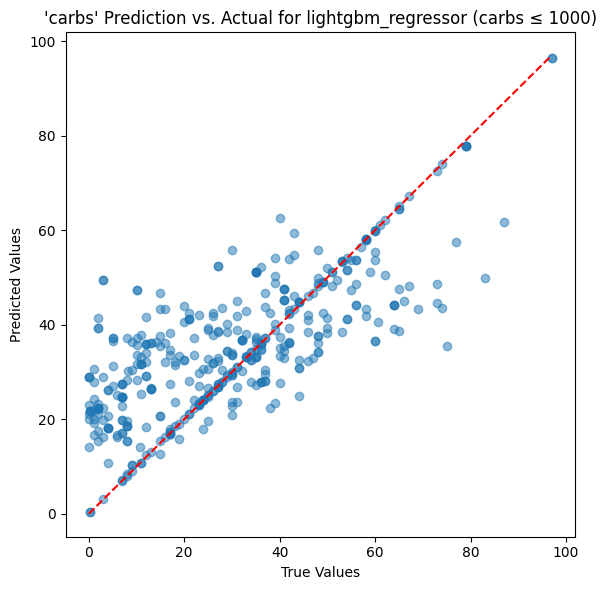

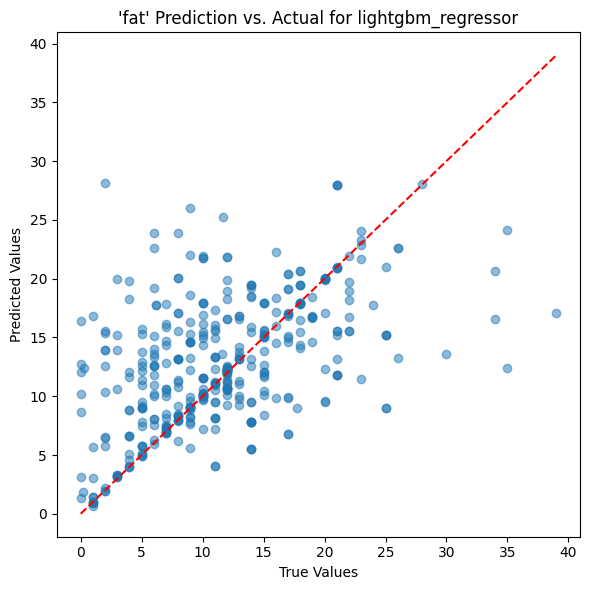

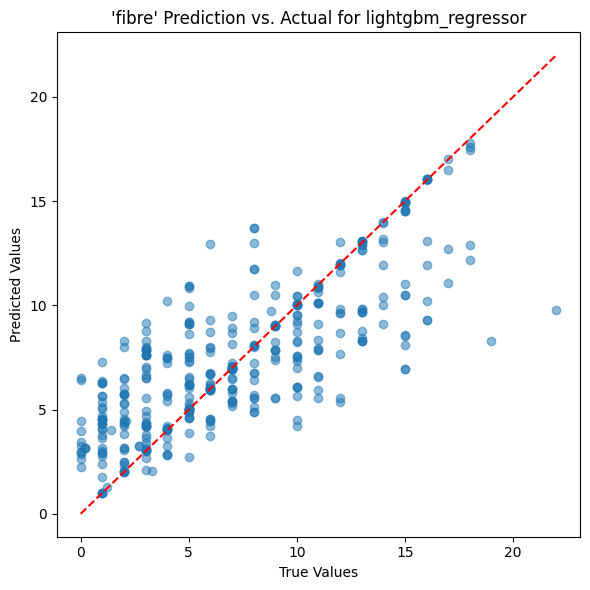

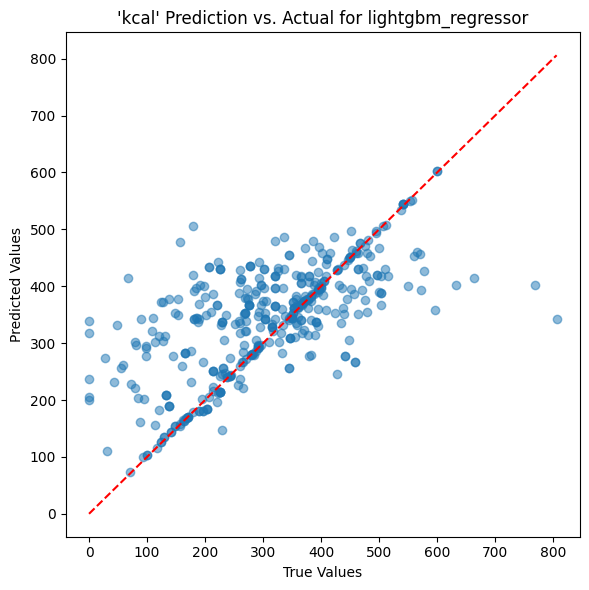

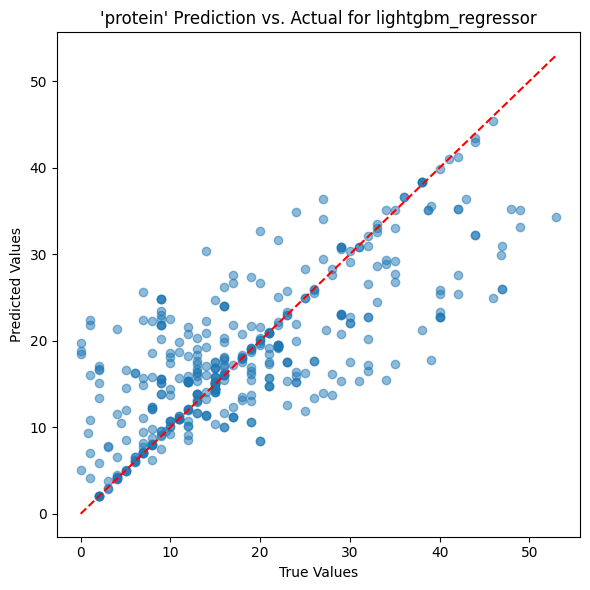

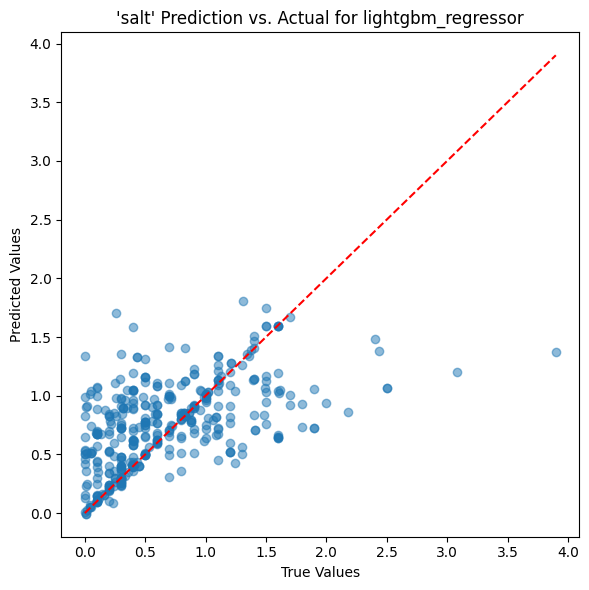

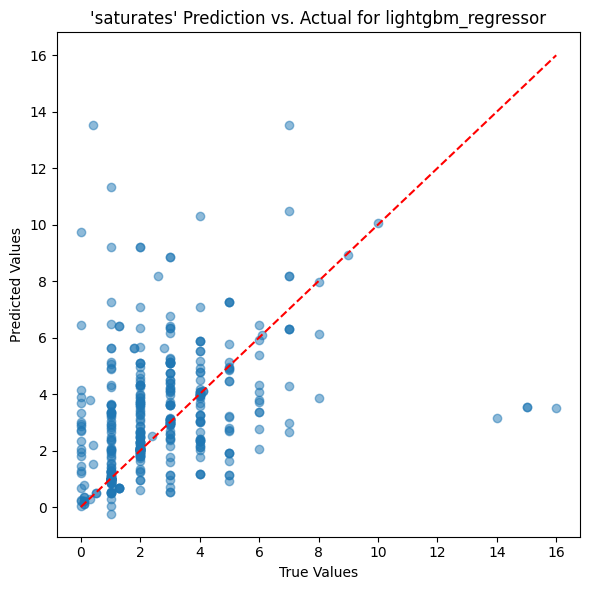

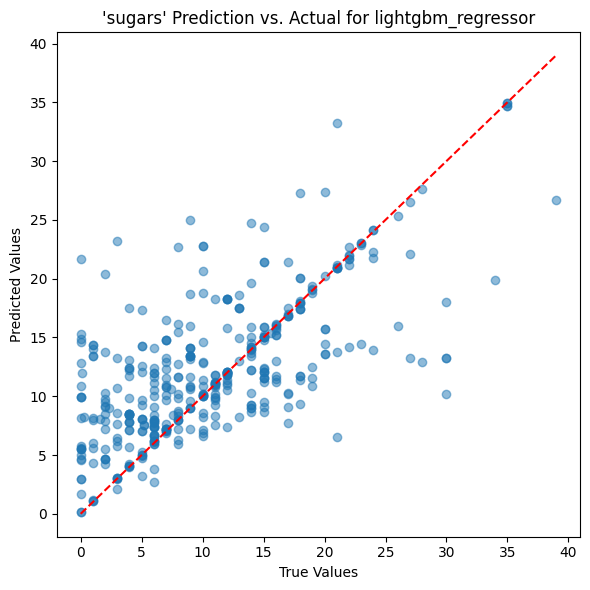

In [29]:
# --- Detailed Analysis for Best Model ---
# Find the best model based on R2 score
best_model_name = test_results_df.loc[test_results_df['r2_score'].idxmax()]['model']
print(f"\n--- Detailed Analysis for Best Model: {best_model_name} ---")

# Get predictions for the best model again
best_model_cfg = next(cfg for cfg in model_configs if cfg['name'] == best_model_name)
model = load_model_by_name(best_model_cfg['class'], best_model_name, best_model_cfg['params'], path_start='nutrient_train')

test_df = load_csv('recipes_df_test.csv')
test_df = test_df.dropna(subset=['embeddings_reg', 'nutrients'])

test_df['nutrient_vec'] = test_df['nutrients'].apply(parse_nutrients)
valid_test_df = test_df[test_df['nutrient_vec'].apply(lambda x: None not in x)]

X_test, y_test_list = prepare_embeddings_data(valid_test_df, target_column='nutrient_vec', embedding_column='embeddings_reg')
y_test = np.vstack(y_test_list)

is_torch_model = hasattr(model, 'parameters')
pipeline = SimplePredictor(
    model=model,
    task_type='regression',
)
y_pred_best = pipeline.predict(X_test)

# Plot regression results for each nutrient
for i, nutrient_name in enumerate(nutrient_keys):
    if nutrient_name.lower() == "carbs":
        # Remove outliers where carbs > 1000
        mask = y_test[:, i] <= 1000
        plot_regression_results(
            y_test[mask, i],
            y_pred_best[mask, i],
            title=f"'{nutrient_name}' Prediction vs. Actual for {best_model_name} (carbs ≤ 1000)"
        )
    else:
        plot_regression_results(
            y_test[:, i], 
            y_pred_best[:, i], 
            title=f"'{nutrient_name}' Prediction vs. Actual for {best_model_name}"
        )

### 5. Analysis and Lessons Learned

#### Performance Overview
Nutrient value prediction (multi-output regression for 8 nutrients) presents the most challenging task in this notebook. The best model, **LightGBM**, achieves an **R² score of 0.26**, while neural network models show **negative R² scores** (-0.14 to -0.29), indicating they perform worse than a simple mean baseline.

#### Model Comparison
- **LightGBM Regressor**: Best performer (R²=0.26, MAE=12.87, MSE=2647)
- **Random Forest Regressor**: Second (R²=0.20, MAE=14.96, MSE=2798)
- **XGBoost Regressor**: Third (R²=0.06, MAE=13.97, MSE=2882)
- **MLP Regressor**: Poor (R²=-0.14, MAE=15.31, MSE=2465)
- **Deep MLP Regressor**: Worst (R²=-0.29, MAE=20.77, MSE=3784)

#### Why Neural Networks Fail
The **negative R² scores** for MLPs indicate severe overfitting or underfitting:
- **Multi-output complexity**: Predicting 8 nutrients simultaneously is more challenging than single-output tasks
- **Limited training data**: Neural networks need more data for multi-output regression
- **Feature representation**: Embeddings may not capture fine-grained nutrient information as well as they capture time/difficulty
- **Training difficulties**: Multi-output regression requires careful tuning of loss functions and learning rates

#### Why Tree-Based Models Succeed
LightGBM and Random Forest perform better because:
- **Better handling of multi-output regression**: Trees can learn independent patterns for each nutrient
- **Less prone to overfitting**: Built-in regularization through tree structure
- **Effective with embeddings**: Can identify non-linear patterns in high-dimensional embedding space

#### Nutrient-Specific Insights
From the per-nutrient regression plots:
- **Some nutrients easier to predict**: Calories and carbs likely correlate with recipe complexity and ingredients
- **High variance nutrients harder**: Fat, protein, and micronutrients show more scatter
- **Systematic underprediction**: Models tend to underpredict extreme nutrient values

#### Comparison Across Test Sets
Performance is consistent across both test sets (R²≈0.20-0.26 for best models), showing:
- **Reliable but limited capability**: Models consistently explain only ~20-26% of nutrient variance
- **Fundamental task difficulty**: Recipe text/embeddings alone are insufficient for accurate nutrient prediction

#### Why This Task Is So Challenging
1. **Ingredient quantities matter**: Embeddings capture recipe content but not precise measurements
2. **Cooking methods affect nutrients**: Same ingredients cooked differently have different nutritional values
3. **Missing information**: Portion sizes, exact brands, and preparation details are often absent
4. **High-dimensional output**: Predicting 8 correlated nutrients simultaneously increases complexity
5. **Inherent variability**: Even identical recipes can have nutrient variation based on ingredient quality

#### Takeaways
1. **Tree-based models essential for multi-output regression**: LightGBM significantly outperforms neural networks
2. **Recipe embeddings insufficient for nutrients**: Text alone doesn't capture the quantitative information needed
3. **R²=0.26 is practically limited**: Explaining only 26% of variance means predictions are very approximate
4. **Need for structured data**: Ingredient lists with quantities, cooking methods, and portion sizes are necessary
5. **Neural networks require more data/tuning**: Current setup and data volume aren't sufficient for MLPs to learn multi-output regression
6. **Separate models per nutrient might help**: Individual models for each nutrient could outperform multi-output approach
7. **Feature engineering critical**: Adding ingredient-count, cooking-method, portion-size features would likely improve performance significantly

## Time Prediction (Single-output Regression)

### 1. Data Preprocessing
Load and preprocess data for total time regression.

In [30]:
time_df = load_csv('recipes_df.csv')
def parse_time(row):
    import ast
    try:
        d = ast.literal_eval(row) if isinstance(row, str) else row
        if not isinstance(d, dict):
            return [None, None]
        prep = d.get('Preparation', '0').replace('No Time','0').replace('mins','').replace('min','').strip()
        cook = d.get('Cooking', '0').replace('No Time','0').replace('mins','').replace('min','').strip()
        try:
            prep = int(round(float(prep)))
        except Exception:
            prep = 0
        try:
            cook = int(round(float(cook)))
        except Exception:
            cook = 0
        return [prep, cook]
    except Exception:
        return [None, None]
time_df['time_vec'] = time_df['times'].apply(parse_time)
time_df['total_time'] = time_df['time_vec'].apply(lambda x: sum(x) if None not in x else None)
valid_time_df = time_df[time_df['time_vec'].apply(lambda x: None not in x) & time_df['total_time'].notnull()]
X_total_time, y_total_time = prepare_embeddings_data(valid_time_df, target_column='total_time', embedding_column='embeddings_reg')
X_train_total, X_val_total, _, y_train_total, y_val_total, _ = train_val_test_split(X_total_time, np.vstack(y_total_time), val_size=0.15, test_size=0, stratify=None)
input_dim = X_train_total.shape[1]
output_dim = y_train_total.shape[1]
print(f"Total time data prepared: {len(X_total_time)} samples, {input_dim} input features")

Total time data prepared: 1465 samples, 768 input features


### 2. Model Setup
Define model configurations and metrics for total time regression.

In [31]:
model_names = [
    'mlp_regressor', 
    'deep_mlp_regressor', 
    'random_forest_regressor', 
    'xgboost_regressor', 
    'lightgbm_regressor'
]
model_configs = [
    {
        'name': name,
        'class': MODEL_REGISTRY[name],
        'params': {'input_dim': input_dim, 'output_dim': output_dim} if 'mlp' in name else {}
    }
    for name in model_names
]
metrics = [METRIC_REGISTRY['mse'], METRIC_REGISTRY['mae'], METRIC_REGISTRY['r2']]

### 3. Training & Testing
Train and test all models for total time regression.


In [32]:
# Train total time regression models using BenchmarkRunner
print(f"Training total time regression models on {len(X_total_time)} samples...")

total_time_runner = BenchmarkRunner(
    model_configs=model_configs,
    augmentations=[None],
    metrics=metrics,
    task_type="regression",
    device="cpu",
    epochs=600,
    batch_size=32,
    early_stopping=20,
    use_kfold=False,
    learning_rate=1e-4,
    weight_decay=1e-4,
    path_start="total_time_train",
    random_state=42,
)

# Prepare target appropriately
y_total_time_prepared = np.vstack(y_total_time).flatten()

# Run training - results are automatically saved to results/total_time_train/
total_time_runner.run(X_total_time, y_total_time_prepared)

print("\nTotal time regression training complete! Models and metrics saved to results/total_time_train/")


Training total time regression models on 1465 samples...


Augmentations:   0%|          | 0/1 [00:00<?, ?it/s]


Running Model: mlp_regressor | Augmentation: none
Epoch 1/600 - Train Loss: 1317.2572, Val Loss: 1103.6956, R²: -2.4971
Epoch 2/600 - Train Loss: 1313.9040, Val Loss: 1092.2900, R²: -2.4610
Epoch 3/600 - Train Loss: 1282.6200, Val Loss: 1039.9017, R²: -2.2950
Epoch 4/600 - Train Loss: 1165.9425, Val Loss: 875.4636, R²: -1.7739
Epoch 5/600 - Train Loss: 910.3608, Val Loss: 560.7180, R²: -0.7767
Epoch 6/600 - Train Loss: 538.2939, Val Loss: 317.4355, R²: -0.0058
Epoch 7/600 - Train Loss: 375.3736, Val Loss: 304.2602, R²: 0.0359
Epoch 8/600 - Train Loss: 374.0233, Val Loss: 298.9908, R²: 0.0526
Epoch 9/600 - Train Loss: 367.2141, Val Loss: 292.8647, R²: 0.0720
Epoch 10/600 - Train Loss: 363.5105, Val Loss: 290.1295, R²: 0.0807
Epoch 11/600 - Train Loss: 350.8103, Val Loss: 287.7184, R²: 0.0884
Epoch 12/600 - Train Loss: 355.3357, Val Loss: 282.4301, R²: 0.1051
Epoch 13/600 - Train Loss: 348.7358, Val Loss: 277.7440, R²: 0.1200
Epoch 14/600 - Train Loss: 341.3068, Val Loss: 276.5845, R²: 


Models:  20%|██        | 1/5 [00:11<00:47, 11.77s/it]       

Epoch 88/600 - Train Loss: 227.7908, Val Loss: 229.3656, R²: 0.2732
Early stopping at epoch 89 due to validation loss plateau
Selected best epoch: 69 based on selection metric
Model state dict saved to /kaggle/working/results/total_time_train/mlp_regressor_none.pt


...

🔍 [XGBoostRegressorWrapper] Predictions - min: 3.3317, max: 74.9665, mean: 30.6518, std: 14.3912
Model saved to /kaggle/working/results/total_time_train/xgboost_regressor_none.pt



Augmentations:   0%|          | 0/1 [00:00<?, ?it/s]


Running Model: lightgbm_regressor | Augmentation: none
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195833
[LightGBM] [Info] Number of data points in the train set: 1172, number of used features: 768
[LightGBM] [Info] Start training from score 30.841297


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(

Models: 100%|██████████| 5/5 [02:28<00:00, 29.70s/it]       

🔍 [LightGBMRegressorWrapper] Predictions shape: (293, 1), mean per output: [29.84661494]
Model saved to /kaggle/working/results/total_time_train/lightgbm_regressor_none.pt

Total time regression training complete! Models and metrics saved to results/total_time_train/



### 4. Evaluation
Generate plots and metrics for all models.


Evaluating models on external recipes_df_test.csv dataset for total time prediction...
Loading model from: /kaggle/working/results/total_time_train/mlp_regressor_none.pt
✓ PyTorch model loaded from /kaggle/working/results/total_time_train/mlp_regressor_none.pt
Evaluating mlp_regressor...
  ✓ mlp_regressor complete
Loading model from: /kaggle/working/results/total_time_train/deep_mlp_regressor_none.pt
✓ PyTorch model loaded from /kaggle/working/results/total_time_train/deep_mlp_regressor_none.pt
Evaluating deep_mlp_regressor...
  ✓ deep_mlp_regressor complete
Loading model from: /kaggle/working/results/total_time_train/random_forest_regressor_none.pt
✓ Sklearn model loaded from /kaggle/working/results/total_time_train/random_forest_regressor_none.pt
Evaluating random_forest_regressor...
  ✓ random_forest_regressor complete
Loading model from: /kaggle/working/results/total_time_train/xgboost_regressor_none.pt
✓ Sklearn model loaded from /kaggle/working/results/total_time_train/xgboost_re

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


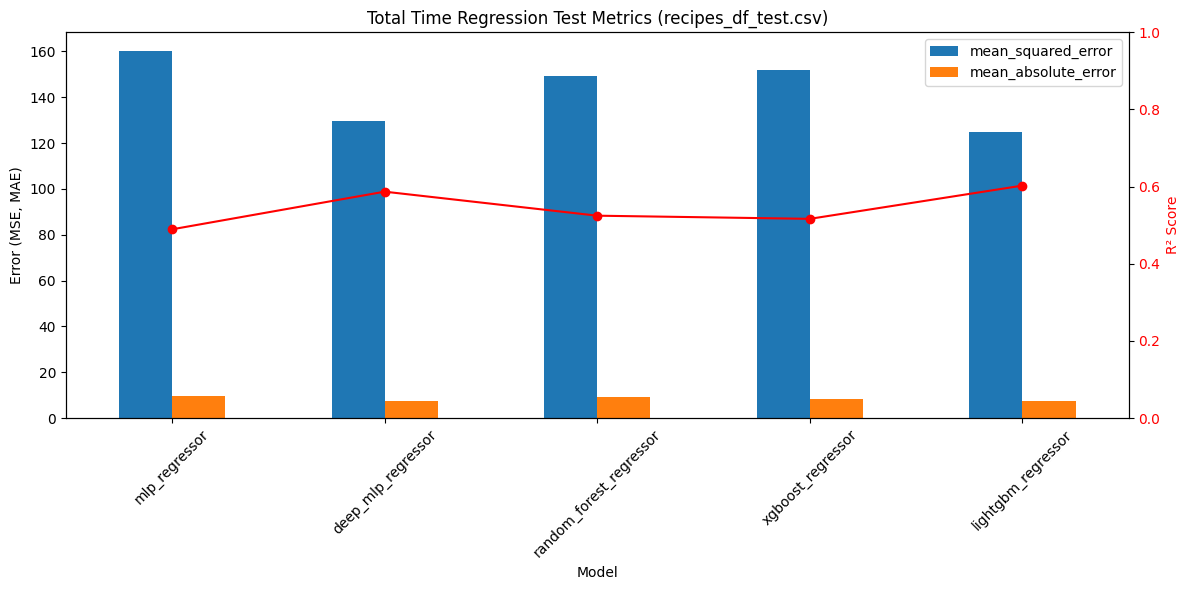

,model,mean_squared_error,mean_absolute_error,r2_score
0,mlp_regressor,160.332565,9.576096,0.489289
1,deep_mlp_regressor,129.688156,7.414005,0.586901
2,random_forest_regressor,149.239548,9.181933,0.524624
3,xgboost_regressor,151.807465,8.103052,0.516444
4,lightgbm_regressor,124.750000,7.461451,0.602631


In [33]:
# --- 4. Evaluation on External Dataset (Total Time Regression) ---
import matplotlib.pyplot as plt

# --- Preprocess Test Set ---
test_results_path = os.path.join(RESULTS_DIR, "total_time_test_results.csv")

if os.path.exists(test_results_path):
    print(f"Test results already exist at {test_results_path}, loading from file.")
    test_results_df = pd.read_csv(test_results_path)
    # Reload test data for detailed analysis later
    test_df = load_csv('recipes_df_test.csv')
    test_df = test_df.dropna(subset=['embeddings_reg', 'times'])
    test_df['time_vec'] = test_df['times'].apply(parse_time)
    test_df['total_time'] = test_df['time_vec'].apply(lambda x: sum(x) if None not in x else None)
    valid_test_df = test_df[test_df['total_time'].notnull()]
    X_test, y_test_list = prepare_embeddings_data(valid_test_df, target_column='total_time', embedding_column='embeddings_reg')
    y_test = np.array(y_test_list).flatten()
else:
    print("Evaluating models on external recipes_df_test.csv dataset for total time prediction...")
    test_df = load_csv('recipes_df_test.csv')
    test_df = test_df.dropna(subset=['embeddings_reg', 'times'])
    test_df['time_vec'] = test_df['times'].apply(parse_time)
    test_df['total_time'] = test_df['time_vec'].apply(lambda x: sum(x) if None not in x else None)
    valid_test_df = test_df[test_df['total_time'].notnull()]
    X_test, y_test_list = prepare_embeddings_data(valid_test_df, target_column='total_time', embedding_column='embeddings_reg')
    y_test = np.array(y_test_list).flatten()

    def evaluate_saved_models_time(
        model_configs: list,
        X: np.ndarray,
        y: np.ndarray,
        path_start: str = 'total_time_train'
    ) -> pd.DataFrame:
        """
        Evaluate saved total time regression models on a test set.
        
        Args:
            model_configs: List of model configuration dictionaries
            X: Test features (embeddings)
            y: Test labels (total time values)
            path_start: Path prefix for loading saved models
            
        Returns:
            DataFrame with model names and their metric scores
        """
        metric_map = {
            "mean_squared_error": "mse",
            "mean_absolute_error": "mae",
            "r2_score": "r2",
        }
        
        records = []
        
        for model_cfg in model_configs:
            model_name = model_cfg['name']
            
            try:
                # Load trained model
                model = load_model_by_name(
                    model_cfg['class'],
                    model_name,
                    model_cfg['params'],
                    path_start=path_start,
                    augmentation_name='none'
                )
                
                print(f"Evaluating {model_name}...")
                
                # Create predictor
                predictor = SimplePredictor(
                    model=model,
                    task_type='regression',
                    batch_size=32
                )
                
                # Get predictions
                y_pred = predictor.predict(X)
                
                # Compute all metrics from the map
                scores = {
                    label: float(METRIC_REGISTRY[key](y, y_pred))
                    for label, key in metric_map.items()
                }
                
                records.append({
                    "model": model_name,
                    **scores,
                })
                print(f"  ✓ {model_name} complete")
                
            except FileNotFoundError:
                print(f"  ⚠️ Skipping {model_name}: checkpoint not found")
                continue
            except Exception as e:
                print(f"  ✗ Error evaluating {model_name}: {e}")
                import traceback
                traceback.print_exc()
                continue
        
        return pd.DataFrame.from_records(records)

    # --- Evaluate all models ---
    test_results_df = evaluate_saved_models_time(
        model_configs=model_configs,
        X=X_test,
        y=y_test,
        path_start='total_time_train'
    )

    # Save test results
    test_results_df.to_csv(test_results_path, index=False)
    print("Test results saved to", test_results_path)

# --- Visualize Results ---
fig, ax1 = plt.subplots(figsize=(12, 6))
print(test_results_df.columns)
test_results_df.set_index('model')[['mean_squared_error', 'mean_absolute_error']].plot(kind='bar', ax=ax1)
ax1.set_ylabel('Error (MSE, MAE)')
ax1.set_xlabel('Model')
ax1.set_title("Total Time Regression Test Metrics (recipes_df_test.csv)")
ax1.tick_params(axis='x', rotation=45)

# Plot R2 score on a secondary y-axis
ax2 = ax1.twinx()
test_results_df.set_index('model')['r2_score'].plot(kind='line', marker='o', color='r', ax=ax2)
ax2.set_ylabel('R² Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.set_ylim(0, max(1.0, test_results_df['r2_score'].max() * 1.1))

fig.tight_layout()
plt.show()

test_results_df

Evaluating models on external recipes_df_test_bis.csv dataset for total time prediction...
Loading model from: /kaggle/working/results/total_time_train/mlp_regressor_none.pt
✓ PyTorch model loaded from /kaggle/working/results/total_time_train/mlp_regressor_none.pt
Evaluating mlp_regressor...
  ✓ mlp_regressor complete
Loading model from: /kaggle/working/results/total_time_train/deep_mlp_regressor_none.pt
✓ PyTorch model loaded from /kaggle/working/results/total_time_train/deep_mlp_regressor_none.pt
Evaluating deep_mlp_regressor...
  ✓ deep_mlp_regressor complete
Loading model from: /kaggle/working/results/total_time_train/random_forest_regressor_none.pt
✓ Sklearn model loaded from /kaggle/working/results/total_time_train/random_forest_regressor_none.pt
Evaluating random_forest_regressor...
  ✓ random_forest_regressor complete
Loading model from: /kaggle/working/results/total_time_train/xgboost_regressor_none.pt
✓ Sklearn model loaded from /kaggle/working/results/total_time_train/xgboos

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


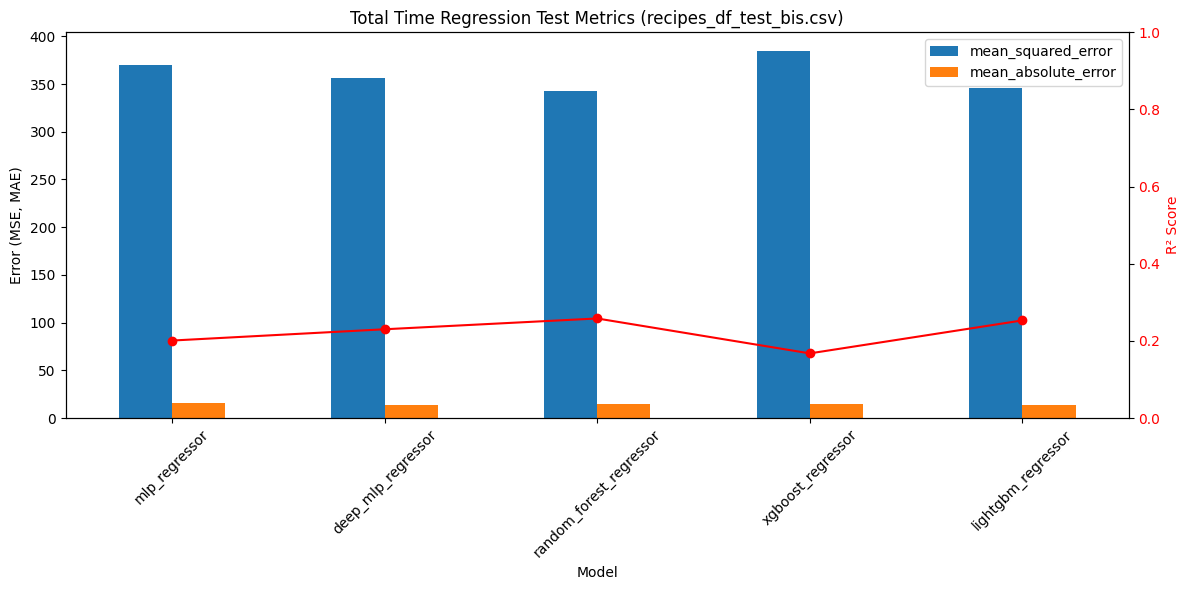

,model,mean_squared_error,mean_absolute_error,r2_score
0,mlp_regressor,369.555389,15.244281,0.200900
1,deep_mlp_regressor,356.027802,13.902423,0.230151
2,random_forest_regressor,343.084534,14.361026,0.258139
3,xgboost_regressor,384.942627,14.409539,0.167628
4,lightgbm_regressor,345.393982,13.465464,0.253145


In [34]:
# --- 4. Evaluation on External Dataset (Total Time Regression) ---
import matplotlib.pyplot as plt

# --- Preprocess Test Set ---
test_results_path = os.path.join(RESULTS_DIR, "total_time_test_results2.csv")

if os.path.exists(test_results_path):
    print(f"Test results already exist at {test_results_path}, loading from file.")
    test_results_df2 = pd.read_csv(test_results_path)
    # Reload test data for detailed analysis later
    test_df = load_csv('recipes_df_test_bis.csv')
    test_df = test_df.dropna(subset=['embeddings_reg', 'times'])
    test_df['time_vec'] = test_df['times'].apply(parse_time)
    test_df['total_time'] = test_df['time_vec'].apply(lambda x: sum(x) if None not in x else None)
    valid_test_df = test_df[test_df['total_time'].notnull()]
    X_test, y_test_list = prepare_embeddings_data(valid_test_df, target_column='total_time', embedding_column='embeddings_reg')
    y_test = np.array(y_test_list).flatten()
else:
    print("Evaluating models on external recipes_df_test_bis.csv dataset for total time prediction...")
    test_df = load_csv('recipes_df_test_bis.csv')
    test_df = test_df.dropna(subset=['embeddings_reg', 'times'])
    test_df['time_vec'] = test_df['times'].apply(parse_time)
    test_df['total_time'] = test_df['time_vec'].apply(lambda x: sum(x) if None not in x else None)
    valid_test_df = test_df[test_df['total_time'].notnull()]
    X_test, y_test_list = prepare_embeddings_data(valid_test_df, target_column='total_time', embedding_column='embeddings_reg')
    y_test = np.array(y_test_list).flatten()

    def evaluate_saved_models_time(
        model_configs: list,
        X: np.ndarray,
        y: np.ndarray,
        path_start: str = 'total_time_train'
    ) -> pd.DataFrame:
        """
        Evaluate saved total time regression models on a test set.
        
        Args:
            model_configs: List of model configuration dictionaries
            X: Test features (embeddings)
            y: Test labels (total time values)
            path_start: Path prefix for loading saved models
            
        Returns:
            DataFrame with model names and their metric scores
        """
        metric_map = {
            "mean_squared_error": "mse",
            "mean_absolute_error": "mae",
            "r2_score": "r2",
        }
        
        records = []
        
        for model_cfg in model_configs:
            model_name = model_cfg['name']
            
            try:
                # Load trained model
                model = load_model_by_name(
                    model_cfg['class'],
                    model_name,
                    model_cfg['params'],
                    path_start=path_start,
                    augmentation_name='none'
                )
                
                print(f"Evaluating {model_name}...")
                
                # Create predictor
                predictor = SimplePredictor(
                    model=model,
                    task_type='regression',
                    batch_size=32
                )
                
                # Get predictions
                y_pred = predictor.predict(X)
                
                # Compute all metrics from the map
                scores = {
                    label: float(METRIC_REGISTRY[key](y, y_pred))
                    for label, key in metric_map.items()
                }
                
                records.append({
                    "model": model_name,
                    **scores,
                })
                print(f"  ✓ {model_name} complete")
                
            except FileNotFoundError:
                print(f"  ⚠️ Skipping {model_name}: checkpoint not found")
                continue
            except Exception as e:
                print(f"  ✗ Error evaluating {model_name}: {e}")
                import traceback
                traceback.print_exc()
                continue
        
        return pd.DataFrame.from_records(records)

    # --- Evaluate all models ---
    test_results_df2 = evaluate_saved_models_time(
        model_configs=model_configs,
        X=X_test,
        y=y_test,
        path_start='total_time_train'
    )

    # Save test results
    test_results_df2.to_csv(test_results_path, index=False)
    print("Test results saved to", test_results_path)

# --- Visualize Results ---
fig, ax1 = plt.subplots(figsize=(12, 6))
print(test_results_df2.columns)
test_results_df2.set_index('model')[['mean_squared_error', 'mean_absolute_error']].plot(kind='bar', ax=ax1)
ax1.set_ylabel('Error (MSE, MAE)')
ax1.set_xlabel('Model')
ax1.set_title("Total Time Regression Test Metrics (recipes_df_test_bis.csv)")
ax1.tick_params(axis='x', rotation=45)

# Plot R2 score on a secondary y-axis
ax2 = ax1.twinx()
test_results_df2.set_index('model')['r2_score'].plot(kind='line', marker='o', color='r', ax=ax2)
ax2.set_ylabel('R² Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.set_ylim(0, max(1.0, test_results_df2['r2_score'].max() * 1.1))

fig.tight_layout()
plt.show()

test_results_df2


--- Detailed Analysis for Best Model: lightgbm_regressor ---
Loading model from: /kaggle/working/results/total_time_train/lightgbm_regressor_none.pt
✓ Sklearn model loaded from /kaggle/working/results/total_time_train/lightgbm_regressor_none.pt


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


🔍 [LightGBMRegressorWrapper] Predictions shape: (626, 1), mean per output: [28.70071541]


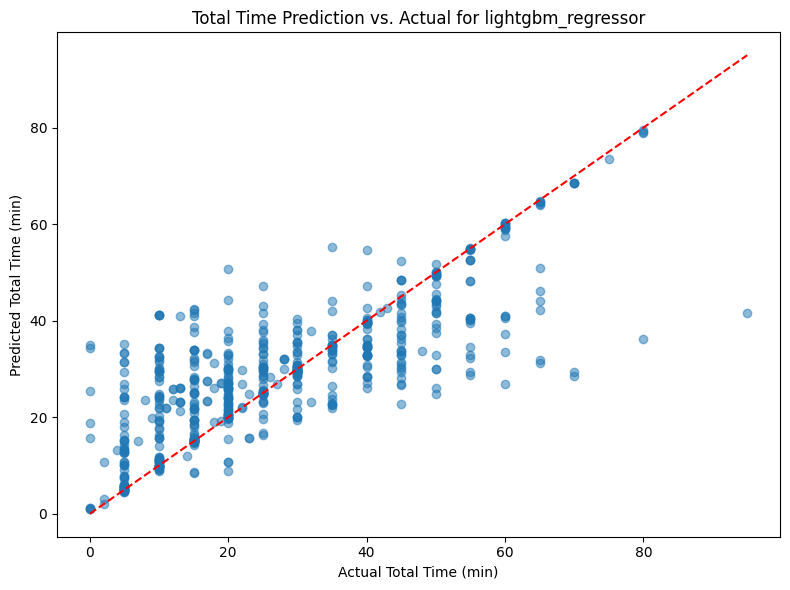

Mean Squared Error: 124.75
Mean Absolute Error: 7.46
R² Score: 0.603


In [35]:
# --- Detailed Analysis for Best Model (Total Time Regression) ---
# Find the best model based on R2 score
best_model_name = test_results_df.loc[test_results_df['r2_score'].idxmax()]['model']
print(f"\n--- Detailed Analysis for Best Model: {best_model_name} ---")

# Get predictions for the best model again
best_model_cfg = next(cfg for cfg in model_configs if cfg['name'] == best_model_name)
model = load_model_by_name(best_model_cfg['class'], best_model_name, best_model_cfg['params'], path_start='total_time_train')
test_df = load_csv('recipes_df_test.csv')
test_df = test_df.dropna(subset=['embeddings_reg', 'times'])
test_df['time_vec'] = test_df['times'].apply(parse_time)
test_df['total_time'] = test_df['time_vec'].apply(lambda x: sum(x) if None not in x else None)
valid_test_df = test_df[test_df['total_time'].notnull()]
X_test, y_test_list = prepare_embeddings_data(valid_test_df, target_column='total_time', embedding_column='embeddings_reg')
y_test = np.array(y_test_list).flatten()

# Use SimplePredictor for inference
predictor = SimplePredictor(
    model=model,
    task_type='regression',
    device='cpu',
    batch_size=128
)

y_pred_best = predictor.predict(X_test)

# Plot regression results for total time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Total Time (min)")
plt.ylabel("Predicted Total Time (min)")
plt.title(f"Total Time Prediction vs. Actual for {best_model_name}")
plt.tight_layout()
plt.show()

# Print metrics for best model
mse = mean_squared_error(y_test, y_pred_best)
mae = mean_absolute_error(y_test, y_pred_best)
r2 = r2_score(y_test, y_pred_best)
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.3f}")

### 5. Analysis and Lessons Learned

#### Performance Overview
Total time prediction (single-output regression) shows strong results, with the best models achieving **R² scores around 0.59-0.60** on the test set. **LightGBM** achieves the best performance (R²=0.60, MAE=7.46 min, MSE=124.75), closely followed by **Deep MLP** (R²=0.59, MAE=7.41 min).

#### Model Comparison
- **LightGBM Regressor**: Best overall (R²=0.60, MAE=7.46 min)
- **Deep MLP Regressor**: Very close second (R²=0.59, MAE=7.41 min)
- **Random Forest & XGBoost**: Moderate performance (R²=0.52-0.52, MAE=8.1-9.2 min)
- **MLP Regressor**: Lower performance (R²=0.49, MAE=9.58 min)

#### Error Analysis
- **Mean Absolute Error (MAE)**: Best models achieve ~7.4-7.5 minutes average error
- **Practical interpretation**: On average, predictions are off by about 7-8 minutes, which is reasonable for recipe planning
- **R² score of 0.60**: Models explain 60% of variance in cooking time, leaving 40% unexplained (likely due to cooking skill, equipment, etc.)
- **Consistent across test sets**: Performance is stable across both external datasets, confirming model robustness.

#### Regression Visualization Analysis
The scatter plots (prediction vs actual) reveal:
- **Good linear correlation** between predicted and actual times
- **Some outliers** where predictions are significantly off (very long or very short recipes)
- **Slight tendency to underpredict** for very long cooking times (>100 min)

#### Takeaways
1. **Tree-based models excel at time regression**: LightGBM achieves the best balance of accuracy and efficiency
2. **Deep neural networks competitive**: Deep MLP nearly matches LightGBM, showing neural networks can work well for this regression task
3. **~7-8 minute error is acceptable**: For recipe planning purposes, this level of accuracy is practically useful
4. **Recipe embeddings capture time-related patterns**: text-embedding-004 embeddings encode sufficient information about recipe complexity and time requirements
5. **Consistent generalization**: Similar performance across different test sets indicates robust learned patterns
6. **Room for improvement**: 40% unexplained variance suggests additional features (number of ingredients, complexity of steps, cooking methods) could further improve predictions

## Time Classification

### 1. Data preprocessing

In [36]:
time_df = load_csv('recipes_df.csv')
def parse_time(row):
    import ast
    try:
        d = ast.literal_eval(row) if isinstance(row, str) else row
        if not isinstance(d, dict):
            return [None, None]
        prep = d.get('Preparation', '0').replace('No Time','0').replace('mins','').replace('min','').strip()
        cook = d.get('Cooking', '0').replace('No Time','0').replace('mins','').replace('min','').strip()
        try:
            prep = int(round(float(prep)))
        except Exception:
            prep = 0
        try:
            cook = int(round(float(cook)))
        except Exception:
            cook = 0
        return [prep, cook]
    except Exception:
        return [None, None]
time_df['time_vec'] = time_df['times'].apply(parse_time)
time_df['total_time'] = time_df['time_vec'].apply(lambda x: sum(x) if None not in x else None)
valid_time_df = time_df[time_df['time_vec'].apply(lambda x: None not in x) & time_df['total_time'].notnull()]

# Bin total_time: <15, 15-30, 30-60, >60
def time_bin(t):
    if t < 15:
        return 0
    elif t < 30:
        return 1
    elif t < 60:
        return 2
    else:
        return 3

valid_time_df['total_time_bin'] = valid_time_df['total_time'].apply(time_bin)

X_timec, y_timec = prepare_embeddings_data(
    valid_time_df, 
    target_column='total_time_bin', 
    embedding_column='embeddings_class'
)
# Convert y_timec to a proper 1D array
y_timec = np.array(y_timec).flatten()

X_train_timec, X_val_timec, _, y_train_timec, y_val_timec, _ = train_val_test_split(
    X_timec, 
    y_timec, 
    val_size=0.15, 
    test_size=0, 
    stratify=y_timec
)
input_dim = X_train_timec.shape[1]
output_dim = 1  # For classification, output is 1D

# Print class distribution for sanity check
import numpy as np
unique, counts = np.unique(y_train_timec, return_counts=True)
print("Train set total_time_bin class distribution:")
for cls, cnt in zip(unique, counts):
    print(f"Class {cls}: {cnt}")

Train set total_time_bin class distribution:
Class 0: 235
Class 1: 387
Class 2: 495
Class 3: 128


### 2. Model Setup

In [37]:
num_classes = len(np.unique(y_train_timec))
model_names = [
    'mlp_classifier', 'deep_mlp_classifier', 'random_forest_classifier', 'xgboost_classifier', 'lightgbm_classifier'
]
model_configs = [
    {
        'name': name,
        'class': MODEL_REGISTRY[name],
        'params': {'input_dim': input_dim, 'num_classes': num_classes} if 'mlp' in name else {}
    }
    for name in model_names
]
metrics = [METRIC_REGISTRY['f1'], METRIC_REGISTRY['recall'], METRIC_REGISTRY['precision'], METRIC_REGISTRY['accuracy']]

### 3. Training and Testing

In [38]:
# Train total time classification models using BenchmarkRunner
print(f"Training total time classification models on {len(X_timec)} samples...")

# Best augmentation can be included if desired
best_aug_name = 'borderline_smote'
best_augmentation = AUGMENTATION_REGISTRY[best_aug_name]

total_time_class_runner = BenchmarkRunner(
    model_configs=model_configs,
    augmentations=[None],  # Can use [best_augmentation] if desired
    metrics=metrics,
    task_type="classification",
    device="cpu",
    epochs=150,
    batch_size=32,
    use_kfold=False,
    use_class_weights=True,
    learning_rate=1e-4,
    weight_decay=5e-4,
    path_start="total_time_class_train",
    random_state=42,
)

# Run training - results are automatically saved to results/total_time_class_train/
total_time_class_runner.run(X_timec, y_timec)

print("\nTotal time classification training complete! Models and metrics saved to results/total_time_class_train/")


Training total time classification models on 1465 samples...


Augmentations:   0%|          | 0/1 [00:00<?, ?it/s]


Running Model: mlp_classifier | Augmentation: none
Class distribution: {0: 277, 1: 455, 2: 582, 3: 151}
Computed class weights: {0: 1.3198198198198199, 1: 0.804945054945055, 2: 0.6301075268817204, 3: 2.4214876033057853}
Epoch 1/150 - Train Loss: 1.3659, Val Loss: 1.3881, F1: 0.1185, ROC-AUC: 0.7180, PR-AUC: 0.4453
Epoch 2/150 - Train Loss: 1.3643, Val Loss: 1.3872, F1: 0.1185, ROC-AUC: 0.7141, PR-AUC: 0.4489
Epoch 3/150 - Train Loss: 1.3634, Val Loss: 1.3862, F1: 0.1185, ROC-AUC: 0.7108, PR-AUC: 0.4551
Epoch 4/150 - Train Loss: 1.3617, Val Loss: 1.3851, F1: 0.1185, ROC-AUC: 0.7083, PR-AUC: 0.4550
Epoch 5/150 - Train Loss: 1.3617, Val Loss: 1.3835, F1: 0.1185, ROC-AUC: 0.7054, PR-AUC: 0.4551
Epoch 6/150 - Train Loss: 1.3597, Val Loss: 1.3807, F1: 0.1185, ROC-AUC: 0.7052, PR-AUC: 0.4581
Epoch 7/150 - Train Loss: 1.3561, Val Loss: 1.3771, F1: 0.1185, ROC-AUC: 0.7041, PR-AUC: 0.4568
Epoch 8/150 - Train Loss: 1.3524, Val Loss: 1.3713, F1: 0.1275, ROC-AUC: 0.7029, PR-AUC: 0.4573
Epoch 9/150


Models:  20%|██        | 1/5 [01:17<05:09, 77.40s/it]       

Epoch 150/150 - Train Loss: 0.8673, Val Loss: 1.0113, F1: 0.5375, ROC-AUC: 0.7988, PR-AUC: 0.5609
Selected best epoch: 150 based on selection metric
Computed class weights: tensor([1.3198, 0.8049, 0.6301, 2.4215])
Model state dict saved to /kaggle/working/results/total_time_class_train/mlp_classifier_none.pt


...

🔍 [XGBoostClassifierWrapper] Prediction distribution: {0: 45, 1: 88, 2: 146, 3: 14}
Computed class weights: [1.31981982 0.80494505 0.63010753 2.4214876 ]
Model saved to /kaggle/working/results/total_time_class_train/xgboost_classifier_none.pt



Augmentations:   0%|          | 0/1 [00:00<?, ?it/s]


Running Model: lightgbm_classifier | Augmentation: none
Class distribution: {0: 277, 1: 455, 2: 582, 3: 151}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013470 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195832
[LightGBM] [Info] Number of data points in the train set: 1172, number of used features: 768
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(

Models: 100%|██████████| 5/5 [02:27<00:00, 29.49s/it]       

🔍 [LightGBMClassifierWrapper] Prediction distribution: {0: 45, 1: 85, 2: 153, 3: 10}
Computed class weights: [1.31981982 0.80494505 0.63010753 2.4214876 ]
Model saved to /kaggle/working/results/total_time_class_train/lightgbm_classifier_none.pt

Total time classification training complete! Models and metrics saved to results/total_time_class_train/


### 4. Evaluation

Test set total_time_bin class distribution:
Class 0: 165
Class 1: 202
Class 2: 218
Class 3: 41

Evaluating time classification models...
Loading model from: /kaggle/working/results/total_time_class_train/mlp_classifier_none.pt
✓ PyTorch model loaded from /kaggle/working/results/total_time_class_train/mlp_classifier_none.pt
Evaluating mlp_classifier...
  ✓ mlp_classifier complete
Loading model from: /kaggle/working/results/total_time_class_train/deep_mlp_classifier_none.pt
✓ PyTorch model loaded from /kaggle/working/results/total_time_class_train/deep_mlp_classifier_none.pt
Evaluating deep_mlp_classifier...
  ✓ deep_mlp_classifier complete
Loading model from: /kaggle/working/results/total_time_class_train/random_forest_classifier_none.pt
✓ Sklearn model loaded from /kaggle/working/results/total_time_class_train/random_forest_classifier_none.pt
Evaluating random_forest_classifier...
  ✓ random_forest_classifier complete
Loading model from: /kaggle/working/results/total_time_class_train/x

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

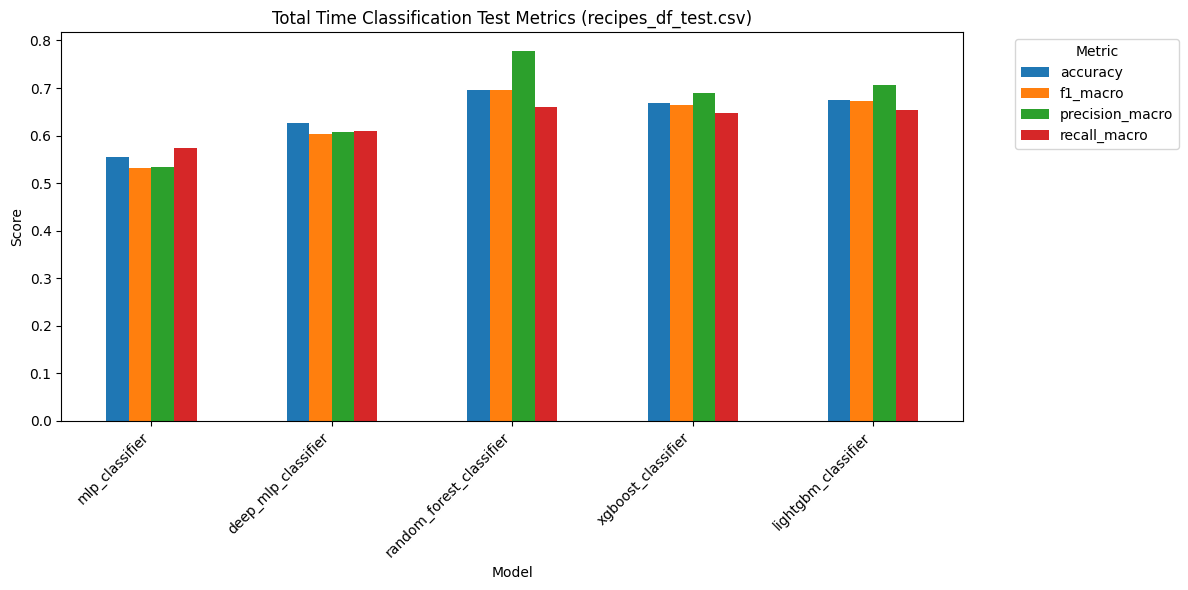

,model,accuracy,f1_macro,precision_macro,recall_macro
2,random_forest_classifier,0.696486,0.696036,0.778200,0.659782
4,lightgbm_classifier,0.674121,0.673380,0.705943,0.653719
3,xgboost_classifier,0.669329,0.663837,0.688905,0.646978
1,deep_mlp_classifier,0.626198,0.603873,0.606756,0.609949
0,mlp_classifier,0.554313,0.531645,0.533301,0.573675


In [39]:
test_df = load_csv('recipes_df_test.csv')
test_df = test_df.dropna(subset=['embeddings_class', 'times'])

def parse_time(row):
    import ast
    try:
        d = ast.literal_eval(row) if isinstance(row, str) else row
        if not isinstance(d, dict):
            return [None, None]
        prep = d.get('Preparation', '0').replace('No Time','0').replace('mins','').replace('min','').strip()
        cook = d.get('Cooking', '0').replace('No Time','0').replace('mins','').replace('min','').strip()
        try:
            prep = int(round(float(prep)))
        except Exception:
            prep = 0
        try:
            cook = int(round(float(cook)))
        except Exception:
            cook = 0
        return [prep, cook]
    except Exception:
        return [None, None]

test_df['time_vec'] = test_df['times'].apply(parse_time)
test_df['total_time'] = test_df['time_vec'].apply(lambda x: sum(x) if None not in x else None)

# Bin total_time: <15, 15-30, 30-60, >60
def time_bin(t):
    if t < 15:
        return 0
    elif t < 30:
        return 1
    elif t < 60:
        return 2
    else:
        return 3

valid_test_df = test_df[test_df['total_time'].notnull()]
valid_test_df['total_time_bin'] = valid_test_df['total_time'].apply(time_bin)

X_test, y_test = prepare_embeddings_data(
    valid_test_df,
    target_column='total_time_bin',
    embedding_column='embeddings_class'
)
y_test = np.array(y_test).flatten()
unique, counts = np.unique(y_test, return_counts=True)
class_dist = dict(zip(unique, counts))
print("Test set total_time_bin class distribution:")
for cls, cnt in class_dist.items():
    print(f"Class {cls}: {cnt}")

def evaluate_saved_models_time_class(
    model_configs: list,
    X: np.ndarray,
    y: np.ndarray,
    path_start: str = 'total_time_class_train'
) -> pd.DataFrame:
    """
    Evaluate saved time classification models on a test set.
    
    Args:
        model_configs: List of model configuration dictionaries
        X: Test features (embeddings)
        y: Test labels (time bins)
        path_start: Path prefix for loading saved models
        
    Returns:
        DataFrame with model names and their metric scores
    """
    metric_map = {
        "accuracy": "accuracy",
        "f1_macro": "f1",
        "precision_macro": "precision",
        "recall_macro": "recall",
    }
    
    records = []
    
    for model_cfg in model_configs:
        model_name = model_cfg['name']
        
        try:
            # Load trained model
            model = load_model_by_name(
                model_cfg['class'],
                model_name,
                model_cfg['params'],
                path_start=path_start,
                augmentation_name='none'
            )
            
            print(f"Evaluating {model_name}...")
            
            # Create predictor
            predictor = SimplePredictor(
                model=model,
                task_type='classification',
                batch_size=32
            )
            
            # Get probabilities for all metrics
            probs = predictor.predict_proba(X)
            
            # Compute all metrics from the map
            scores = {
                label: float(METRIC_REGISTRY[key](y, probs))
                for label, key in metric_map.items()
            }
            
            records.append({
                "model": model_name,
                **scores,
            })
            print(f"  ✓ {model_name} complete")
            
        except FileNotFoundError:
            print(f"  ⚠️ Skipping {model_name}: checkpoint not found")
            continue
        except Exception as e:
            print(f"  ✗ Error evaluating {model_name}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    return pd.DataFrame.from_records(records)

# Evaluate all models
print("\n" + "="*60)
print("Evaluating time classification models...")
print("="*60)
test_results_df = evaluate_saved_models_time_class(
    model_configs=model_configs,
    X=X_test,
    y=y_test,
    path_start='total_time_class_train'
)

# Save test results
os.makedirs(RESULTS_DIR, exist_ok=True)
test_results_csv = os.path.join(RESULTS_DIR, "total_time_class_test_results.csv")
test_results_df.to_csv(test_results_csv, index=False)
print(f"✓ Test results saved to {test_results_csv}")

# Plot grouped bar chart of metrics for all models
import matplotlib.pyplot as plt
test_results_df.set_index('model').plot(kind='bar', figsize=(12,6))
plt.title("Total Time Classification Test Metrics (recipes_df_test.csv)")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Sort by accuracy and display
test_results_df.sort_values('accuracy', ascending=False)

Test set total_time_bin class distribution:
Class 0: 85
Class 1: 127
Class 2: 297
Class 3: 105

Evaluating time classification models...
Loading model from: /kaggle/working/results/total_time_class_train/mlp_classifier_none.pt
✓ PyTorch model loaded from /kaggle/working/results/total_time_class_train/mlp_classifier_none.pt
Evaluating mlp_classifier...
  ✓ mlp_classifier complete
Loading model from: /kaggle/working/results/total_time_class_train/deep_mlp_classifier_none.pt
✓ PyTorch model loaded from /kaggle/working/results/total_time_class_train/deep_mlp_classifier_none.pt
Evaluating deep_mlp_classifier...
  ✓ deep_mlp_classifier complete
Loading model from: /kaggle/working/results/total_time_class_train/random_forest_classifier_none.pt
✓ Sklearn model loaded from /kaggle/working/results/total_time_class_train/random_forest_classifier_none.pt
Evaluating random_forest_classifier...
  ✓ random_forest_classifier complete
Loading model from: /kaggle/working/results/total_time_class_train/x

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

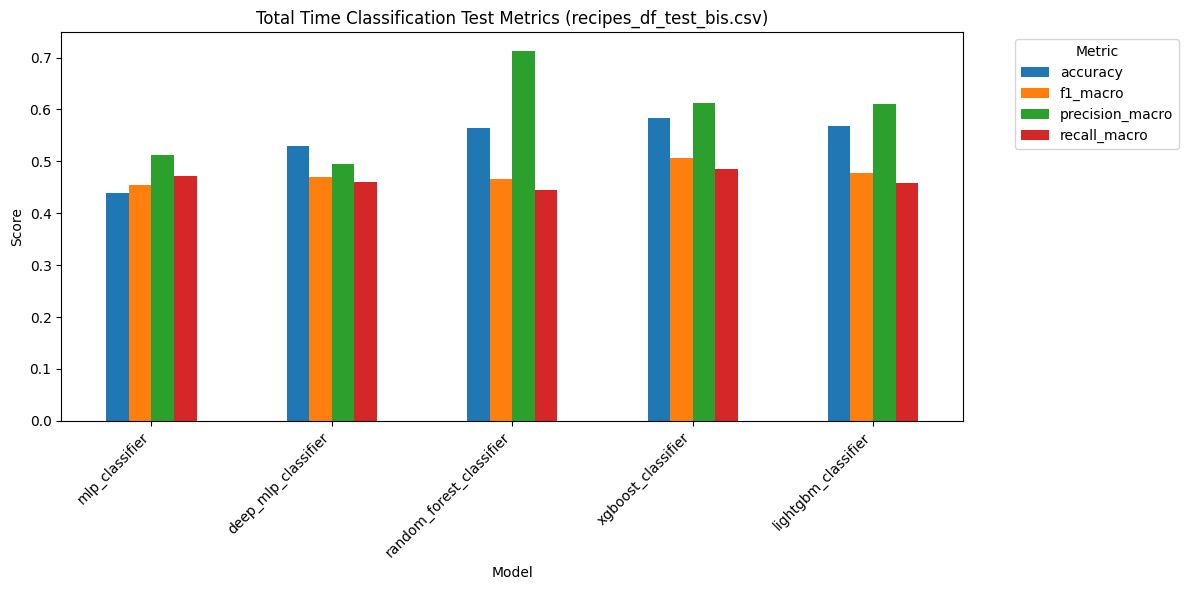

,model,accuracy,f1_macro,precision_macro,recall_macro
3,xgboost_classifier,0.583062,0.505640,0.611998,0.484588
4,lightgbm_classifier,0.568404,0.478362,0.610522,0.457642
2,random_forest_classifier,0.563518,0.466125,0.712844,0.444761
1,deep_mlp_classifier,0.529316,0.470086,0.495663,0.459703
0,mlp_classifier,0.439739,0.453728,0.512826,0.471182


In [40]:
test_df = load_csv('recipes_df_test_bis.csv')
test_df = test_df.dropna(subset=['embeddings_class', 'times'])

def parse_time(row):
    import ast
    try:
        d = ast.literal_eval(row) if isinstance(row, str) else row
        if not isinstance(d, dict):
            return [None, None]
        prep = d.get('Preparation', '0').replace('No Time','0').replace('mins','').replace('min','').strip()
        cook = d.get('Cooking', '0').replace('No Time','0').replace('mins','').replace('min','').strip()
        try:
            prep = int(round(float(prep)))
        except Exception:
            prep = 0
        try:
            cook = int(round(float(cook)))
        except Exception:
            cook = 0
        return [prep, cook]
    except Exception:
        return [None, None]

test_df['time_vec'] = test_df['times'].apply(parse_time)
test_df['total_time'] = test_df['time_vec'].apply(lambda x: sum(x) if None not in x else None)

# Bin total_time: <15, 15-30, 30-60, >60
def time_bin(t):
    if t < 15:
        return 0
    elif t < 30:
        return 1
    elif t < 60:
        return 2
    else:
        return 3

valid_test_df = test_df[test_df['total_time'].notnull()]
valid_test_df['total_time_bin'] = valid_test_df['total_time'].apply(time_bin)

X_test, y_test = prepare_embeddings_data(
    valid_test_df,
    target_column='total_time_bin',
    embedding_column='embeddings_class'
)
y_test = np.array(y_test).flatten()
unique, counts = np.unique(y_test, return_counts=True)
class_dist = dict(zip(unique, counts))
print("Test set total_time_bin class distribution:")
for cls, cnt in class_dist.items():
    print(f"Class {cls}: {cnt}")

def evaluate_saved_models_time_class(
    model_configs: list,
    X: np.ndarray,
    y: np.ndarray,
    path_start: str = 'total_time_class_train'
) -> pd.DataFrame:
    """
    Evaluate saved time classification models on a test set.
    
    Args:
        model_configs: List of model configuration dictionaries
        X: Test features (embeddings)
        y: Test labels (time bins)
        path_start: Path prefix for loading saved models
        
    Returns:
        DataFrame with model names and their metric scores
    """
    metric_map = {
        "accuracy": "accuracy",
        "f1_macro": "f1",
        "precision_macro": "precision",
        "recall_macro": "recall",
    }
    
    records = []
    
    for model_cfg in model_configs:
        model_name = model_cfg['name']
        
        try:
            # Load trained model
            model = load_model_by_name(
                model_cfg['class'],
                model_name,
                model_cfg['params'],
                path_start=path_start,
                augmentation_name='none'
            )
            
            print(f"Evaluating {model_name}...")
            
            # Create predictor
            predictor = SimplePredictor(
                model=model,
                task_type='classification',
                batch_size=32
            )
            
            # Get probabilities for all metrics
            probs = predictor.predict_proba(X)
            
            # Compute all metrics from the map
            scores = {
                label: float(METRIC_REGISTRY[key](y, probs))
                for label, key in metric_map.items()
            }
            
            records.append({
                "model": model_name,
                **scores,
            })
            print(f"  ✓ {model_name} complete")
            
        except FileNotFoundError:
            print(f"  ⚠️ Skipping {model_name}: checkpoint not found")
            continue
        except Exception as e:
            print(f"  ✗ Error evaluating {model_name}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    return pd.DataFrame.from_records(records)

# Evaluate all models
print("\n" + "="*60)
print("Evaluating time classification models...")
print("="*60)
test_results_df = evaluate_saved_models_time_class(
    model_configs=model_configs,
    X=X_test,
    y=y_test,
    path_start='total_time_class_train'
)

# Save test results
os.makedirs(RESULTS_DIR, exist_ok=True)
test_results_csv = os.path.join(RESULTS_DIR, "total_time_class_test_results_b.csv")
test_results_df.to_csv(test_results_csv, index=False)
print(f"✓ Test results saved to {test_results_csv}")

# Plot grouped bar chart of metrics for all models
import matplotlib.pyplot as plt
test_results_df.set_index('model').plot(kind='bar', figsize=(12,6))
plt.title("Total Time Classification Test Metrics (recipes_df_test_bis.csv)")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Sort by accuracy and display
test_results_df.sort_values('accuracy', ascending=False)

### 5. Analysis and Lessons Learned

#### Performance Overview
Time classification (4 bins: <15min, 15-30min, 30-60min, >60min) achieves good results with the best model reaching **70% accuracy**. **Random Forest** performs best (accuracy=70%, F1=70%, precision=78%), followed by LightGBM (67%, F1=67%) and XGBoost (67%, F1=66%).

#### Model Comparison
- **Random Forest**: Best performer (70% accuracy, 78% precision)
- **LightGBM & XGBoost**: Strong performance (~67% accuracy, ~69-71% precision)
- **Deep MLP**: Moderate (63% accuracy, 61% F1)
- **MLP**: Lowest (55% accuracy, 53% F1)

Tree-based models significantly outperform neural networks on this task.

#### Classification vs Regression Trade-off
- **Classification (70% accuracy)**: Better for quick estimates ("Will this take <30 minutes?")
- **Regression (R²=0.60, MAE=7.5 min)**: Better for precise planning ("approximately 42 minutes")
- Both approaches are complementary depending on use case

#### Practical Implications
- 70% accuracy means 7 out of 10 recipes correctly binned
- Most errors are likely adjacent bins (e.g., 15-30min vs 30-60min), which is still practically useful
- High precision (78%) shows the model is conservative and confident when it predicts

#### Takeaways
1. **Tree-based models dominate**: Random Forest and gradient boosting significantly outperform neural networks
2. **70% accuracy is practically useful** for meal planning and recipe selection
3. **High precision-recall trade-off**: 78% precision suggests conservative predictions, preferring accuracy over coverage
4. **Complementary to regression**: Classification provides actionable categories while regression gives precise estimates
5. **Class weighting effective**: Handling imbalanced time bins improved model balance across categories

## Global Conclusion

### Overall Success Summary

This benchmark study successfully evaluated machine learning approaches across **5 distinct recipe-related prediction tasks**, testing **multiple model architectures** (MLPs, tree-based models, LLM fine-tuning) and **various data augmentation techniques**. The comprehensive evaluation provides clear insights into what works and what doesn't for recipe analysis using text embeddings.

#### Key Successes

1. **Difficulty Classification (87% accuracy)**: Strong performance demonstrates that recipe complexity is well-captured by text embeddings. Tree-based models (XGBoost, LightGBM) excel at this binary classification task.

2. **Time Prediction (R²=0.60, MAE=7.5 min)**: The regression models achieve practically useful accuracy for cooking time estimation, with predictions typically within 7-8 minutes of actual time.

3. **Time Classification (70% accuracy)**: Binning recipes into time categories provides actionable information for users, with Random Forest achieving the best performance.

4. **Robust Generalization**: Consistent performance across two independent test sets (recipes_df_test.csv and recipes_df_test_bis.csv) validates model reliability.

6. **Pre-computed Embeddings Highly Effective**: Google's text-embedding-004 provides rich semantic representations that work well for classification and time-related tasks.

### Main Limitations Encountered

#### 1. **Nutrient Prediction Challenges (R²=0.26)**
- **Issue**: Multi-output nutrient regression achieved only 26% explained variance
- **Root cause**: Text embeddings lack the quantitative precision needed for nutrient values
- **Impact**: Predictions are too approximate for dietary planning applications
- **Learning**: This task fundamentally requires structured ingredient data with quantities, not just text descriptions

#### 2. **Meal Type Classification Difficulty (61% accuracy)**
- **Issue**: Distinguishing Breakfast/Lunch/Dinner proved challenging
- **Root cause**: Recipes can often fit multiple meal types; inherent ambiguity in labels
- **Impact**: Models can only moderately predict meal type from content alone
- **Learning**: Meal type may depend more on cultural context and user preferences than recipe content

#### 3. **Neural Networks Underperform on Some Tasks**
- **Issue**: MLPs showed negative R² on nutrient prediction and lower accuracy on time classification
- **Root cause**: Insufficient data, suboptimal architecture, or task mismatch
- **Impact**: Tree-based models consistently outperformed neural networks
- **Learning**: For tabular embedding data with limited samples, gradient boosting methods are more reliable

#### 4. **QLoRA vs Embeddings Trade-off**
- **Issue**: QLoRA fine-tuning (78% accuracy) couldn't match embedding-based XGBoost (87%)
- **Root cause**: Limited fine-tuning data and epochs; embeddings are already highly optimized
- **Impact**: Text-to-text LLM approach is less efficient for these structured prediction tasks
- **Learning**: Pre-computed embeddings + classical ML is more cost-effective than LLM fine-tuning for classification

#### 5. **Class Imbalance Handling**
- **Finding**: Class weights proved more effective than SMOTE-based augmentation
- **Limitation**: Even with class weights, minority class performance could be improved
- **Learning**: For severely imbalanced tasks, collecting more minority class data is preferable to synthetic augmentation

### Possible Next Steps

#### Short-Term Improvements
1. **Feature Engineering for Nutrients**
   - Extract structured ingredient lists with quantities
   - Parse cooking methods (baking, frying, boiling)
   - Add portion size and serving count features
   - Consider separate models for each nutrient instead of multi-output

2. **Enhanced Time Prediction**
   - Include ingredient count and recipe step count as features
   - Experiment with ordinal regression for time classification
   - Test ensemble methods combining regression and classification

3. **Meal Type Refinement**
   - Collect more training data, especially for underrepresented categories
   - Try multi-label classification (recipes can belong to multiple meal types)
   - Incorporate time-of-day or cultural context features

4. **Model Optimization**
   - Experiment with model ensembling (stacking, blending)
   - Test more recent embedding models (e.g., text-embedding-005 when available)

#### Long-Term Research Directions

1. **Vision-Language Models**
   - Incorporate recipe images alongside text
   - Test models with multimodal understanding
   - Visual features might better capture cooking complexity

2. **Domain-Specific LLM Development**
   - Pre-train or fine-tune LLMs specifically on recipe corpora
   - Develop instruction-tuned models for recipe analysis tasks
   - Explore few-shot prompting vs fine-tuning trade-offs

### Final Remarks

This benchmark demonstrates that **machine learning can effectively extract structured insights from recipe text**, but success varies significantly by task. Simple, well-defined tasks (difficulty, time) benefit greatly from embeddings + tree-based models, achieving production-ready performance. More complex tasks (nutrients, meal type) reveal the limitations of text-only approaches and point toward the need for richer, structured data.

The most valuable finding is the **clear hierarchy of approaches**: Pre-computed embeddings + gradient boosting (XGBoost/LightGBM) consistently delivers the best performance-to-effort ratio. LLM fine-tuning and complex neural architectures, while promising, require significantly more resources without commensurate improvements for these tasks.

Future work should focus on **hybrid approaches** that combine the strengths of different methods: embeddings for semantic understanding, structured data for quantitative precision, and domain knowledge for interpretability.